In [2]:
#!/usr/bin/env python3
"""
Within-List T_lag × Retrieval-Retrieval RSA Coupling Analysis
----------------------------------------------------------------------
For each subject × session × list, compute the Pearson correlation
between T_lag and RSA_r_ret across recall transitions in that list.
This gives one scalar per list: r(T_lag, RSA_r_ret).

The Fisher-z transformed correlation is then modelled with LMM to test:
  - Does temporal clustering predict stronger T_lag–RSA coupling?
  - Is this effect region- and band-specific?

Input : ./rsa_lag_allregions/ALL_SUBJECTS_{exp}_allregions_allbands_rsa_lag.csv
Output: ./rsa_tlag_withinlist/

Models (per region × band):
  Model 1 (bare)       : z_r ~ TCE_score
  Model 2 (controlled) : z_r ~ TCE_score + SCE_score + mean_list_recall

  where TCE_score and SCE_score are subject-level clustering scores
  collapsed from the trial-level SP_lag / T_lag columns.

Random effects: nested session within subject
  groups     = subject
  vc_formula = {'subj_sess': '0 + C(subj_sess)'}

FDR: BH correction within each model across regions.

Outputs (under ./rsa_tlag_withinlist/):
  withinlist_r_per_list_{region}_{band}.csv   — per-list coupling values
  LMM_{region}_{band}_results.csv / .txt      — model results
  plots/hist_r_{region}_{band}.png            — distribution of r values
  plots/scatter_TCE_{region}_{band}.png       — z_r vs TCE scatter
  plots/forest_allregions_{band}.png          — cross-region forest plot
  LMM_ALL_results.csv                         — master file
"""

import warnings
from pathlib import Path
from typing import Optional, Tuple, List

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, ttest_1samp
from statsmodels.regression.mixed_linear_model import MixedLM
from statsmodels.stats.multitest import fdrcorrection

warnings.filterwarnings('ignore')

# ============================================================================
# CONFIGURATION
# ============================================================================

EXPERIMENT  = 'DBOY1'
OUTCOME     = 'RSA_r_ret'          # retrieval × retrieval RSA (primary)
MIN_TRANS   = 3                    # min transitions per list to include

INPUT_DIR   = Path('./rsa_lag_allregions')
OUTPUT_DIR  = Path('./rsa_tlag_withinlist')
PLOT_DIR    = OUTPUT_DIR / 'plots'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)

REGIONS = ['LHP', 'RHP', 'LLTC', 'RLTC', 'LMTL', 'RMTL']
BANDS   = ['theta', 'alpha', 'beta', 'gamma']

# ── Palette ──────────────────────────────────────────────────────────────────
BG_COLOR    = 'white'
AX_COLOR    = '#F7F7F7'
GRID_COLOR  = '#DDDDDD'
TEXT_COLOR  = '#222222'
SPINE_COLOR = '#AAAAAA'

REGION_COLORS = {
    'LHP':  '#1A3A6B',
    'RHP':  '#8B1A1A',
    'LLTC': '#1A6B3A',
    'RLTC': '#6B3A1A',
    'LMTL': '#3A1A6B',
    'RMTL': '#6B1A5A',
}
BAND_COLORS = {
    'theta': '#4575B4',
    'alpha': '#74ADD1',
    'beta':  '#F46D43',
    'gamma': '#D73027',
}


# ============================================================================
# UTILITY
# ============================================================================

def fisher_z(r: np.ndarray) -> np.ndarray:
    """Fisher r-to-z transform, clipped to avoid ±inf."""
    r_clipped = np.clip(r, -0.9999, 0.9999)
    return np.arctanh(r_clipped)


def sig_stars(p: float) -> str:
    return ('***' if p < 0.001 else
            '**'  if p < 0.01  else
            '*'   if p < 0.05  else
            '†'   if p < 0.10  else '')


def _style_ax(ax):
    ax.set_facecolor(AX_COLOR)
    ax.tick_params(colors=TEXT_COLOR, labelsize=8.5)
    ax.xaxis.label.set_color(TEXT_COLOR)
    ax.yaxis.label.set_color(TEXT_COLOR)
    ax.title.set_color(TEXT_COLOR)
    ax.grid(True, color=GRID_COLOR, lw=0.6, zorder=0)
    for spine in ax.spines.values():
        spine.set_edgecolor(SPINE_COLOR)
        spine.set_linewidth(0.8)


# ============================================================================
# DATA LOADING
# ============================================================================

def load_data() -> Optional[pd.DataFrame]:
    fpath = INPUT_DIR / f"ALL_SUBJECTS_{EXPERIMENT}_allregions_allbands_rsa_lag.csv"

    if not fpath.exists():
        print(f"  ✗ Master CSV not found: {fpath}")
        return None

    print(f"  Loading {fpath.name} …")
    df = pd.read_csv(fpath)
    print(f"  Loaded {len(df):,} rows × {len(df.columns)} cols")
    print(f"  Columns: {df.columns.tolist()}")

    # ── Normalise the list column name ───────────────────────────────────────
    # ── Normalise the list column name ───────────────────────────────────────
    # In DBOY1 the list identifier is 'trial'; rename to 'list' for consistency.
    list_candidates = ['list', 'list_num', 'listno', 'list_no',
                       'list_number', 'trial_list', 'listNum', 'trial']
    found = [c for c in list_candidates if c in df.columns]
    if not found:
        found = [c for c in df.columns if 'list' in c.lower()]
    if not found:
        print(f"  ✗ Cannot find a list column. Columns: {df.columns.tolist()}")
        return None
    if found[0] != 'list':
        print(f"  Renaming '{found[0]}' → 'list'")
        df = df.rename(columns={found[0]: 'list'})

    if OUTCOME not in df.columns:
        print(f"  ✗ Outcome column '{OUTCOME}' not found in CSV.")
        print(f"    Columns: {df.columns.tolist()}")
        return None

    if 'T_lag' not in df.columns:
        print(f"  ✗ 'T_lag' column not found in CSV.")
        return None

    df = df[df['region'].isin(REGIONS)].copy()
    df['subject'] = EXPERIMENT + '_' + df['subject'].astype(str)
    print(f"  After region filter: {len(df):,} rows")
    print(f"  Subjects : {df['subject'].nunique()}")
    print(f"  Regions  : {sorted(df['region'].unique())}")
    print(f"  Bands    : {sorted(df['band'].unique())}")
    return df


# ============================================================================
# STEP 1 — WITHIN-LIST CORRELATION
# ============================================================================

def compute_withinlist_coupling(df: pd.DataFrame,
                                 region: str,
                                 band: str) -> pd.DataFrame:
    """
    For each subject × session × list, correlate T_lag with RSA_r_ret.
    Returns one row per list with:
      r_tlag_rsa  — raw Pearson r
      z_r         — Fisher z-transformed r  ← used in LMM
      n_trans     — number of transitions in this list
      mean_rsa    — mean RSA_r_ret for the list
      mean_T_lag  — mean T_lag for the list
      recall_rate — fraction recalled (n_trans / list_length proxy)
    """
    sub = df[
        (df['region'] == region) &
        (df['band']   == band)
    ].copy().dropna(subset=['T_lag', OUTCOME])

    rows = []
    for (subject, session, lst), grp in sub.groupby(
            ['subject', 'session', 'list']):

        grp = grp.dropna(subset=['T_lag', OUTCOME])
        n   = len(grp)
        if n < MIN_TRANS:
            continue

        x = grp['T_lag'].values.astype(float)
        y = grp[OUTCOME].values.astype(float)

        if x.std() == 0 or y.std() == 0:
            continue

        r, p = pearsonr(x, y)

        rows.append({
            'subject':    subject,
            'session':    session,
            'list':       lst,
            'r_tlag_rsa': r,
            'z_r':        fisher_z(np.array([r]))[0],
            'n_trans':    n,
            'mean_rsa':   float(y.mean()),
            'mean_T_lag': float(x.mean()),
            'region':     region,
            'band':       band,
        })

    return pd.DataFrame(rows)


# ============================================================================
# STEP 2 — SUBJECT-LEVEL CLUSTERING SCORES
# ============================================================================

def build_subject_clustering(df: pd.DataFrame) -> pd.DataFrame:
    """
    Collapse T_lag and SP_lag to subject-level mean scores.
    These serve as predictors in the LMM (between-subject component).

    TCE_score = mean T_lag across all transitions for the subject
                (higher = stronger temporal contiguity, i.e. recalling
                 nearby items more often)
    SCE_score = mean SP_lag (spatial analogue)

    Note: if your CSV already has precomputed SP/T clustering scores
    (e.g. SP_clustering, T_clustering), swap the groupby below to use those.
    """
    agg = (df.groupby('subject')
             .agg(TCE_score=('T_lag',  'mean'),
                  SCE_score=('SP_lag', 'mean') if 'SP_lag' in df.columns
                             else ('T_lag', 'mean'))   # fallback
             .reset_index())

    # Z-score across subjects so LMM betas are interpretable
    for col in ['TCE_score', 'SCE_score']:
        s = agg[col].std()
        if s > 0:
            agg[col] = (agg[col] - agg[col].mean()) / s

    return agg


# ============================================================================
# STEP 3 — LMM
# ============================================================================

def fit_lmm(df: pd.DataFrame,
            pred_cols: List[str],
            label: str,
            outcome_col: str = 'z_r'
            ) -> Tuple[Optional[object], int]:
    df = df.copy()
    df['subj_sess'] = (df['subject'].astype(str)
                       + '_' + df['session'].astype(str))

    keep = [outcome_col] + pred_cols + ['subject', 'subj_sess']
    keep = [c for c in keep if c in df.columns]
    df   = df[keep].dropna()

    if len(df) < 20:
        print(f"    [{label}] Too few rows ({len(df)}) — skipping")
        return None, 0

    formula = f"{outcome_col} ~ {' + '.join(pred_cols)}"
    print(f"    [{label}] {formula}  |  N={len(df):,}")

    model = MixedLM.from_formula(
        formula,
        data       = df,
        groups     = df['subject'],
        vc_formula = {'subj_sess': '0 + C(subj_sess)'},
    )

    result = None
    for method in ['lbfgs', 'nm', 'powell']:
        try:
            result = model.fit(reml=True, method=method)
            if np.isfinite(result.llf):
                print(f"    [{label}] optimizer={method}  "
                      f"llf={result.llf:.4f}  AIC={result.aic:.4f}")
                break
        except Exception as e:
            print(f"    [{label}] {method} failed: {e}")
            result = None

    if result is None or not np.isfinite(result.llf):
        print(f"    [{label}] WARNING: fit unsuccessful.")
    return result, len(df)


def extract_rows(result,
                 pred_display: dict,
                 model_label: str,
                 region: str,
                 band: str) -> pd.DataFrame:
    if result is None:
        return pd.DataFrame()
    rows = []
    for col, name in pred_display.items():
        matched = col if col in result.params.index else None
        if matched is None:
            hits    = [k for k in result.params.index
                       if col.lower() in k.lower()]
            matched = hits[0] if hits else None
        if matched is None:
            continue
        rows.append({
            'experiment': EXPERIMENT,
            'outcome':    OUTCOME,
            'region':     region,
            'band':       band,
            'model':      model_label,
            'term':       name,
            'col':        col,
            'beta':       result.params[matched],
            'se':         result.bse[matched],
            'z':          result.tvalues[matched],
            'p_raw':      result.pvalues[matched],
            'llf':        result.llf,
            'aic':        result.aic,
            'nobs':       int(result.nobs),
        })
    return pd.DataFrame(rows)


def apply_fdr(df: pd.DataFrame) -> pd.DataFrame:
    if df.empty:
        return df
    _, df['p_fdr'] = fdrcorrection(df['p_raw'].values)
    return df


def format_block(title: str, rows_df: pd.DataFrame) -> str:
    sep  = '=' * 96
    sep2 = '-' * 96
    hdr  = (f"{'Term':<40} {'β':>9} {'SE':>9} {'z':>8} "
            f"{'p_raw':>10} {'p_fdr':>10} {'AIC':>10} {'N':>8} {'sig':>5}")
    lines = [sep, title, sep2, hdr, sep2]
    for _, row in rows_df.iterrows():
        aic_s = (f"{row['aic']:>10.2f}"
                 if pd.notna(row.get('aic')) else '       NaN')
        p_fdr = row.get('p_fdr', np.nan)
        lines.append(
            f"{row['term']:<40} {row['beta']:>9.4f} {row['se']:>9.4f} "
            f"{row['z']:>8.3f} {row['p_raw']:>10.4f} "
            f"{p_fdr:>10.4f} {aic_s} {int(row['nobs']):>8,} "
            f"{sig_stars(p_fdr):>5}"
        )
    lines += [sep2,
              'DV = Fisher-z(r(T_lag, RSA_r_ret))  per list.',
              'FDR: BH within model across terms.',
              '† p<.10  * p<.05  ** p<.01  *** p<.001',
              sep]
    return '\n'.join(lines)


# ============================================================================
# STEP 4 — PLOTS
# ============================================================================

def plot_r_distribution(list_df: pd.DataFrame,
                         region: str,
                         band: str,
                         save_path: Path):
    """Histogram of within-list r(T_lag, RSA_r_ret) across all lists."""
    r_vals = list_df['r_tlag_rsa'].dropna().values
    if len(r_vals) == 0:
        return

    color     = REGION_COLORS.get(region, '#444444')
    mean_r    = r_vals.mean()
    sem_r     = r_vals.std() / np.sqrt(len(r_vals))
    t_stat, p = ttest_1samp(r_vals, 0)
    p_str     = f'p={p:.3f}' if p >= 0.001 else 'p<0.001'
    stars     = sig_stars(p)

    fig, ax = plt.subplots(figsize=(7, 4))
    fig.patch.set_facecolor(BG_COLOR)
    _style_ax(ax)

    ax.hist(r_vals, bins=25, color=color, alpha=0.75, edgecolor='white',
            linewidth=0.5, zorder=2)
    ax.axvline(0,       color=SPINE_COLOR, lw=1.5, ls='--', zorder=3)
    ax.axvline(mean_r,  color=color,       lw=2.5, ls='-',  zorder=4,
               label=f'Mean r = {mean_r:.3f} ± {sem_r:.3f} SEM\n'
                     f't-test vs 0: {stars} {p_str}')
    ax.axvspan(mean_r - 1.96 * sem_r, mean_r + 1.96 * sem_r,
               color=color, alpha=0.15, zorder=1)

    pct_pos = (r_vals > 0).mean() * 100
    ax.text(0.97, 0.95, f'{pct_pos:.0f}% lists r > 0',
            transform=ax.transAxes, ha='right', va='top',
            fontsize=9, color=TEXT_COLOR, style='italic')

    ax.set_xlabel('r(T_lag, RSA_r_ret)  per list', fontsize=10)
    ax.set_ylabel('Count', fontsize=10)
    ax.set_title(
        f'{region}  |  {band.capitalize()} band  |  '
        f'Within-list T_lag × RSA_r_ret coupling\n'
        f'n = {len(r_vals)} lists  [{EXPERIMENT}]',
        fontsize=10, fontweight='bold')
    ax.legend(facecolor='white', edgecolor=SPINE_COLOR, fontsize=8.5)

    fig.tight_layout()
    fig.savefig(save_path, dpi=150, bbox_inches='tight', facecolor=BG_COLOR)
    plt.close(fig)
    print(f"  ✓ Histogram → {save_path.name}")


def plot_tce_scatter(list_df: pd.DataFrame,
                      clust_df: pd.DataFrame,
                      region: str,
                      band: str,
                      save_path: Path):
    """
    Scatter of subject-mean z_r vs TCE_score.
    One dot per subject; OLS line overlaid.
    """
    subj_mean = (list_df.groupby('subject')['z_r']
                        .mean()
                        .reset_index()
                        .rename(columns={'z_r': 'mean_z_r'}))
    merged    = subj_mean.merge(clust_df[['subject', 'TCE_score']],
                                on='subject', how='inner')

    if len(merged) < 5:
        return

    color       = REGION_COLORS.get(region, '#444444')
    x           = merged['TCE_score'].values
    y           = merged['mean_z_r'].values
    r_val, p_val = pearsonr(x, y)
    p_str       = f'p={p_val:.3f}' if p_val >= 0.001 else 'p<0.001'
    m, b        = np.polyfit(x, y, 1)
    x_line      = np.linspace(x.min(), x.max(), 100)

    fig, ax = plt.subplots(figsize=(7, 5))
    fig.patch.set_facecolor(BG_COLOR)
    _style_ax(ax)

    ax.scatter(x, y, color=color, s=55, alpha=0.75,
               edgecolors='white', linewidths=0.6, zorder=3)
    ax.plot(x_line, m * x_line + b, color=color, lw=2.0, ls='--', zorder=4,
            label=f'OLS  r={r_val:.3f} {p_str}')
    ax.axhline(0, color=SPINE_COLOR, lw=1.0, ls=':', zorder=1)
    ax.axvline(0, color=SPINE_COLOR, lw=1.0, ls=':', zorder=1)

    # Label subjects with extreme z_r
    thresh = np.percentile(np.abs(y), 85)
    for _, row in merged.iterrows():
        if abs(row['mean_z_r']) >= thresh:
            ax.text(row['TCE_score'] + 0.03, row['mean_z_r'],
                    row['subject'].replace(EXPERIMENT + '_', ''),
                    fontsize=6.5, color=TEXT_COLOR, alpha=0.7)

    ax.set_xlabel('TCE score  (z-scored, subject level)', fontsize=10)
    ax.set_ylabel('Mean Fisher-z(r)  per subject', fontsize=10)
    ax.set_title(
        f'{region}  |  {band.capitalize()} band\n'
        f'Subject-level TCE vs. within-list T_lag×RSA coupling\n'
        f'n = {len(merged)} subjects  [{EXPERIMENT}]',
        fontsize=10, fontweight='bold')
    ax.legend(facecolor='white', edgecolor=SPINE_COLOR, fontsize=9)

    fig.tight_layout()
    fig.savefig(save_path, dpi=150, bbox_inches='tight', facecolor=BG_COLOR)
    plt.close(fig)
    print(f"  ✓ TCE scatter → {save_path.name}")


def plot_forest_allregions(all_results: pd.DataFrame,
                            band: str,
                            save_path: Path):
    """
    Cross-region forest plot for one band.
    One row per region, Model 1 and Model 2 side by side.
    Predictor shown: TCE_score.
    """
    sub = all_results[
        (all_results['band'] == band) &
        (all_results['col']  == 'TCE_score')
    ].copy()

    if sub.empty:
        return

    sub['ci_lo'] = sub['beta'] - 1.96 * sub['se']
    sub['ci_hi'] = sub['beta'] + 1.96 * sub['se']

    regions_present = [r for r in REGIONS if r in sub['region'].values]
    if not regions_present:
        return

    fig, ax = plt.subplots(
        figsize=(10, max(4, len(regions_present) * 1.8 + 1.5)))
    fig.patch.set_facecolor(BG_COLOR)
    _style_ax(ax)

    offsets = {'Model1': -0.20, 'Model2': 0.20}
    markers = {'Model1': 'o',   'Model2': 's'}
    labels  = {'Model1': 'Bare', 'Model2': 'Controlled'}

    y_pos   = 0
    yticks  = []
    ylabels = []

    for region in regions_present:
        color = REGION_COLORS.get(region, '#444444')
        for model_key in ['Model1', 'Model2']:
            row = sub[(sub['region'] == region) & (sub['model'] == model_key)]
            if row.empty:
                continue
            row  = row.iloc[0]
            yp   = y_pos + offsets[model_key]
            xerr = [[row['beta'] - row['ci_lo']], [row['ci_hi'] - row['beta']]]
            ax.errorbar(
                row['beta'], yp, xerr=xerr,
                fmt=markers[model_key], color=color, ecolor=color,
                elinewidth=1.4, capsize=3, capthick=1.4,
                markersize=6, zorder=3,
                label=f'{labels[model_key]}' if region == regions_present[0]
                       else '')
            p_show = row.get('p_fdr', row['p_raw'])
            stars  = sig_stars(p_show)
            if stars:
                ax.text(row['ci_hi'] + abs(row['ci_hi'] - row['beta']) * 0.12,
                        yp, stars, color=color, va='center',
                        fontsize=8.5, fontweight='bold')
        yticks.append(y_pos)
        ylabels.append(region)
        y_pos -= 1

    ax.axvline(0, color=SPINE_COLOR, lw=1.2, ls='--', zorder=1)
    ax.set_yticks(yticks)
    ax.set_yticklabels(ylabels, fontsize=10)
    ax.set_xlabel('β  (TCE_score → Fisher-z(r(T_lag, RSA_r_ret)))', fontsize=10)
    ax.set_title(
        f'All regions  |  {band.capitalize()} band\n'
        f'TCE → within-list T_lag×RSA coupling  |  '
        f'○=Bare  □=Controlled  [{EXPERIMENT}]',
        fontsize=10, fontweight='bold', pad=8)
    ax.legend(facecolor='white', edgecolor=SPINE_COLOR, fontsize=9)

    fig.tight_layout()
    fig.savefig(save_path, dpi=150, bbox_inches='tight', facecolor=BG_COLOR)
    plt.close(fig)
    print(f"  ✓ Cross-region forest → {save_path.name}")


def plot_band_summary(all_results: pd.DataFrame,
                       region: str,
                       save_path: Path):
    """
    β bar chart across bands for one region.
    Shows Model1 and Model2 side by side per band.
    Predictor: TCE_score.
    """
    sub = all_results[
        (all_results['region'] == region) &
        (all_results['col']    == 'TCE_score')
    ].copy()

    if sub.empty:
        return

    x      = np.arange(len(BANDS))
    width  = 0.35
    models = ['Model1', 'Model2']
    m_labels = {'Model1': 'Bare', 'Model2': 'Controlled'}
    m_colors = {'Model1': REGION_COLORS.get(region, '#444444'),
                 'Model2': '#888888'}

    fig, ax = plt.subplots(figsize=(9, 5))
    fig.patch.set_facecolor(BG_COLOR)
    _style_ax(ax)

    for i, model_key in enumerate(models):
        betas, errors, pvals = [], [], []
        for band in BANDS:
            row = sub[
                (sub['model'] == model_key) &
                (sub['band']  == band)
            ]
            if row.empty:
                betas.append(np.nan); errors.append(0); pvals.append(1.0)
            else:
                r = row.iloc[0]
                betas.append(r['beta'])
                errors.append(r['se'])
                pvals.append(r.get('p_fdr', r['p_raw']))

        plot_b = [b if np.isfinite(b) else 0 for b in betas]
        plot_e = [e if np.isfinite(betas[j]) else 0
                  for j, e in enumerate(errors)]

        bars = ax.bar(x + i * width - width / 2, plot_b, width,
                      color=m_colors[model_key],
                      yerr=plot_e,
                      error_kw=dict(ecolor=TEXT_COLOR, capsize=3, elinewidth=1),
                      alpha=0.80, label=m_labels[model_key])

        for bar, beta, p in zip(bars, betas, pvals):
            if not np.isfinite(beta):
                continue
            stars = sig_stars(p)
            if stars:
                h    = bar.get_height()
                sign = 1 if h >= 0 else -1
                ax.text(bar.get_x() + bar.get_width() / 2,
                        h + sign * max(abs(h) * 0.06, 0.005),
                        stars, ha='center', va='bottom',
                        color=TEXT_COLOR, fontsize=9, fontweight='bold')

    ax.axhline(0, color=SPINE_COLOR, lw=1.0, ls='--')
    ax.set_xticks(x)
    ax.set_xticklabels([b.capitalize() for b in BANDS], fontsize=10)
    ax.set_xlabel('Frequency Band', fontsize=10)
    ax.set_ylabel('β  (TCE_score → z_r)', fontsize=10)
    ax.set_title(
        f'{region}  |  TCE_score → within-list T_lag×RSA_r_ret coupling\n'
        f'β by band  [{EXPERIMENT}]',
        fontsize=10, fontweight='bold')
    ax.legend(facecolor='white', edgecolor=SPINE_COLOR, fontsize=9)

    fig.tight_layout()
    fig.savefig(save_path, dpi=150, bbox_inches='tight', facecolor=BG_COLOR)
    plt.close(fig)
    print(f"  ✓ Band summary → {save_path.name}")


# ============================================================================
# PER (REGION × BAND) ANALYSIS
# ============================================================================

def run_one_cell(df: pd.DataFrame,
                  clust_df: pd.DataFrame,
                  region: str,
                  band: str) -> Tuple[pd.DataFrame, pd.DataFrame, str]:
    """
    Full pipeline for one region × band cell:
      1. Compute within-list r(T_lag, RSA_r_ret)
      2. Merge subject-level clustering scores
      3. Fit Model1 and Model2
      4. Return (lmm_results_df, list_level_df, text_report)
    """
    print(f"\n  ── {region}  |  {band.capitalize()} ──────────────────────")

    # ── Step 1: within-list correlations ─────────────────────────────────────
    list_df = compute_withinlist_coupling(df, region, band)

    if list_df.empty:
        print(f"    No lists met MIN_TRANS={MIN_TRANS} — skipping")
        return pd.DataFrame(), pd.DataFrame(), ""

    n_lists = len(list_df)
    n_subj  = list_df['subject'].nunique()
    mean_r  = list_df['r_tlag_rsa'].mean()
    pct_pos = (list_df['r_tlag_rsa'] > 0).mean() * 100
    print(f"    Lists : {n_lists}  |  Subjects : {n_subj}")
    print(f"    Mean r(T_lag, RSA_r_ret) = {mean_r:.4f}  "
          f"({pct_pos:.0f}% positive)")

    # ── Step 2: merge subject clustering scores ───────────────────────────────
    merged = list_df.merge(
        clust_df[['subject', 'TCE_score', 'SCE_score']],
        on='subject', how='left')

    # Also include mean_list_recall proxy (mean n_trans / max n_trans)
    max_trans = merged.groupby('subject')['n_trans'].transform('max')
    merged['recall_rate'] = merged['n_trans'] / max_trans.replace(0, np.nan)

    # ── Step 3: LMM ──────────────────────────────────────────────────────────
    all_rows = []
    text_blocks = [
        f"EXPERIMENT: {EXPERIMENT}  |  REGION: {region}  |  BAND: {band}",
        f"DV: Fisher-z(r(T_lag, RSA_r_ret))  per list",
        f"N lists: {n_lists}  |  N subjects: {n_subj}\n",
    ]

    # Model 1: bare
    res1, _ = fit_lmm(merged, ['TCE_score'], 'Model1')
    rows1   = extract_rows(res1,
                            {'TCE_score': 'TCE_score  (temporal clustering)'},
                            'Model1', region, band)
    rows1   = apply_fdr(rows1)
    if not rows1.empty:
        all_rows.append(rows1)
        block1 = format_block(
            f'Model 1 — z_r ~ TCE_score  [{region} / {band}]', rows1)
        text_blocks.append(block1)
        print('\n' + block1)

    # Model 2: controlled
    ctrl_cols = ['TCE_score', 'SCE_score', 'recall_rate']
    ctrl_disp = {
        'TCE_score':   'TCE_score  (temporal clustering)',
        'SCE_score':   'SCE_score  (spatial clustering) [covariate]',
        'recall_rate': 'recall_rate  [covariate]',
    }
    res2, _ = fit_lmm(merged, ctrl_cols, 'Model2')
    rows2   = extract_rows(res2, ctrl_disp, 'Model2', region, band)
    rows2   = apply_fdr(rows2)
    if not rows2.empty:
        all_rows.append(rows2)
        block2 = format_block(
            f'Model 2 — z_r ~ TCE + SCE + recall_rate  [{region} / {band}]',
            rows2)
        text_blocks.append(block2)
        print('\n' + block2)

    result_df = (pd.concat(all_rows, ignore_index=True)
                 if all_rows else pd.DataFrame())
    text      = '\n\n'.join(text_blocks)

    return result_df, list_df, text


# ============================================================================
# ENTRY POINT
# ============================================================================

def main():
    print(f"\n{'='*80}")
    print(f"Within-List T_lag × RSA_r_ret Coupling  [{EXPERIMENT}]")
    print(f"Regions : {REGIONS}")
    print(f"Bands   : {BANDS}")
    print(f"Outcome : {OUTCOME}  (retrieval × retrieval RSA)")
    print(f"Min transitions per list: {MIN_TRANS}")
    print(f"{'='*80}\n")

    # ── Load data ─────────────────────────────────────────────────────────────
    df = load_data()
    if df is None or df.empty:
        print("No data loaded. Exiting.")
        return

    # ── Build subject-level clustering scores ─────────────────────────────────
    clust_df = build_subject_clustering(df)
    print(f"\n  Subject clustering scores computed for "
          f"{len(clust_df)} subjects.")

    ALL_RESULTS = []
    ALL_LISTS   = []

    # ── Main loop: region × band ───────────────────────────────────────────────
    for region in REGIONS:
        print(f"\n{'━'*80}")
        print(f"REGION: {region}")
        print(f"{'━'*80}")

        region_results = []

        for band in BANDS:
            lmm_df, list_df, text = run_one_cell(df, clust_df, region, band)

            if not lmm_df.empty:
                region_results.append(lmm_df)
                ALL_RESULTS.append(lmm_df)

                # Save per-cell LMM results
                tag      = f"{region}_{band}"
                csv_path = OUTPUT_DIR / f"LMM_{tag}_results.csv"
                txt_path = OUTPUT_DIR / f"LMM_{tag}_results.txt"
                lmm_df.to_csv(csv_path, index=False)
                with open(txt_path, 'w') as f:
                    f.write(text)
                print(f"  ✓ LMM results → {csv_path.name}")

            if not list_df.empty:
                ALL_LISTS.append(list_df)

                # Save per-list coupling values
                list_path = (OUTPUT_DIR /
                             f"withinlist_r_per_list_{region}_{band}.csv")
                list_df.to_csv(list_path, index=False)
                print(f"  ✓ List-level coupling → {list_path.name}")

                # Plots
                plot_r_distribution(
                    list_df, region, band,
                    PLOT_DIR / f"hist_r_{region}_{band}.png")

                plot_tce_scatter(
                    list_df, clust_df, region, band,
                    PLOT_DIR / f"scatter_TCE_{region}_{band}.png")

        # Band-summary bar chart for this region
        if region_results:
            reg_df = pd.concat(region_results, ignore_index=True)
            plot_band_summary(
                reg_df, region,
                PLOT_DIR / f"band_summary_{region}.png")

    # ── Cross-region forest plots (one per band) ───────────────────────────────
    if ALL_RESULTS:
        master_df = pd.concat(ALL_RESULTS, ignore_index=True)
        for band in BANDS:
            plot_forest_allregions(
                master_df, band,
                PLOT_DIR / f"forest_allregions_{band}.png")

        # Save master CSV
        master_path = OUTPUT_DIR / 'LMM_ALL_results.csv'
        master_df.to_csv(master_path, index=False)
        print(f"\n{'='*80}")
        print(f"✓ Master LMM results → {master_path.name}  "
              f"({len(master_df):,} rows)")
        print(f"  Regions : {sorted(master_df['region'].unique())}")
        print(f"  Bands   : {sorted(master_df['band'].unique())}")

    # Save master list-level CSV
    if ALL_LISTS:
        all_lists_df   = pd.concat(ALL_LISTS, ignore_index=True)
        all_lists_path = OUTPUT_DIR / 'ALL_withinlist_r.csv'
        all_lists_df.to_csv(all_lists_path, index=False)
        print(f"✓ All per-list coupling values → {all_lists_path.name}  "
              f"({len(all_lists_df):,} rows)")

    print(f"\n{'='*80}")
    print(f"✓ ANALYSIS COMPLETE  [{EXPERIMENT}]")
    print(f"  Results : {OUTPUT_DIR}")
    print(f"  Plots   : {PLOT_DIR}")
    print(f"{'='*80}\n")


if __name__ == '__main__':
    main()


Within-List T_lag × RSA_r_ret Coupling  [DBOY1]
Regions : ['LHP', 'RHP', 'LLTC', 'RLTC', 'LMTL', 'RMTL']
Bands   : ['theta', 'alpha', 'beta', 'gamma']
Outcome : RSA_r_ret  (retrieval × retrieval RSA)
Min transitions per list: 3

  Loading ALL_SUBJECTS_DBOY1_allregions_allbands_rsa_lag.csv …
  Loaded 44,692 rows × 23 cols
  Columns: ['subject', 'session', 'experiment', 'trial', 'region', 'hemisphere', 'band', 'band_freq_indices', 'output_pos_i', 'output_pos_j', 'output_lag', 'word_i', 'word_j', 'serial_pos_i', 'serial_pos_j', 'T_lag', 'SP_lag', 'RSA_r_ret', 'RSA_r_enc', 'RSA_r_enc_i_ret_j', 'RSA_r_enc_j_ret_i', 'n_channels', 'semantic_sim']
  Renaming 'trial' → 'list'
  After region filter: 44,692 rows
  Subjects : 39
  Regions  : ['LHP', 'LLTC', 'LMTL', 'RHP', 'RLTC', 'RMTL']
  Bands    : ['alpha', 'beta', 'gamma', 'theta']

  Subject clustering scores computed for 39 subjects.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
REGION: LHP
━━━━━━━━━━━━━━


Region: LHP  Band: theta  Outcome: RSA_r_ret

RSA rows after filter: 1,814  (27 subjects)

Step 1 -- Within-list r(T_lag, RSA_r_ret)
  Lists:    152  (25 subjects)
  Mean r  = -0.0274  (45% positive)
  t-test vs 0:  t=-0.740  p=0.4607

Step 2 -- After merging TCE: 152 lists  (25 subjects)
  Saved: withinlist_r_tlag_rsa_theta_lhp.csv

Step 3 -- LMM  z_r ~ TCE_z
  Input: 152 lists  (25 subjects)
  Converged (lbfgs)
  beta=0.0432  SE=0.0622  z=0.695  p=0.4873  AIC=nan  N=152


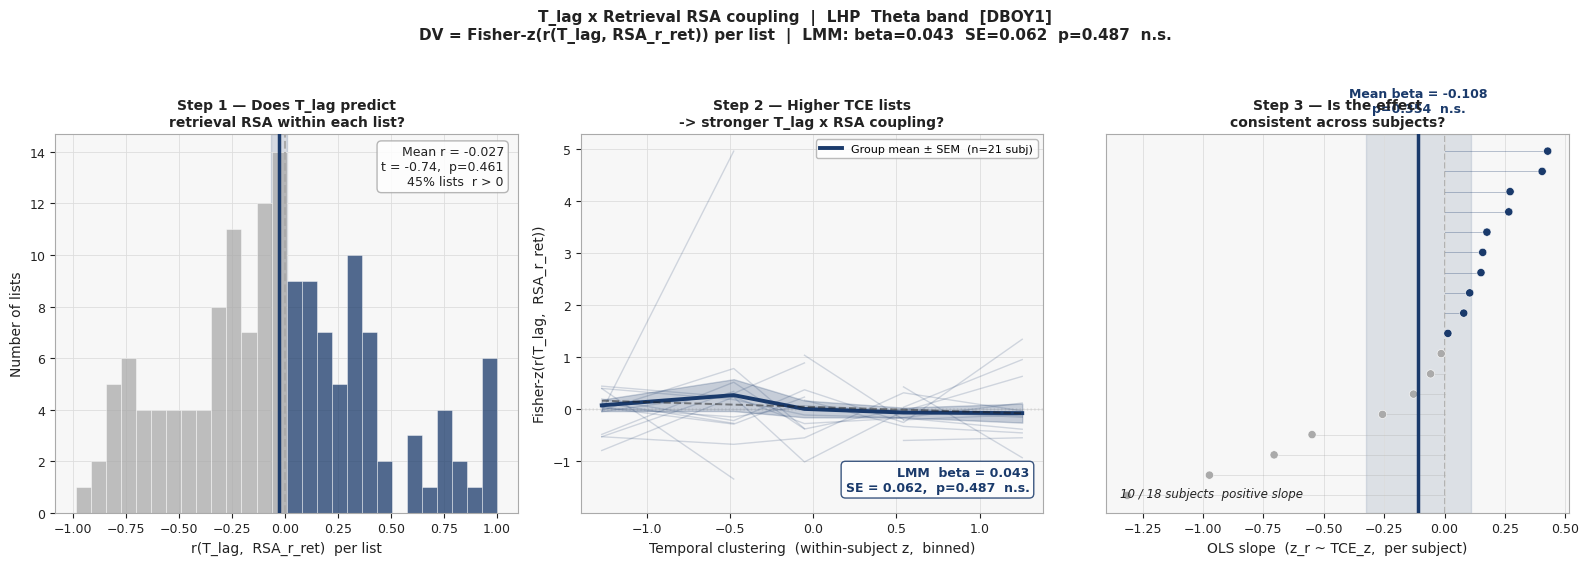


Figure saved: withinlist_tlag_rsa_simple/withinlist_tlag_rsa_theta_lhp.png

DONE



In [1]:
#!/usr/bin/env python3
"""
Within-list r(T_lag, RSA_r_ret) — Theta band, LHP only
=======================================================
Step 1  Per subject x session x list:
          Pearson r(T_lag, RSA_r_ret) across recall transitions
          -> one scalar per list

Step 2  Merge with list-level mean_T_clustering
        (from mean_temporal_clustering_per_list.csv)

Step 3  LMM  (proper repeated-measures inference)
          Fisher-z(r)  ~  TCE_z  +  (1 | subject / session)
          TCE_z = within-subject z-score of mean_T_clustering

Figure  3-panel narrative:
  Panel 1 -- histogram of per-list r  (does T_lag predict RSA at all?)
  Panel 2 -- spaghetti: TCE_z bins vs z_r, one line per subject  (LMM result)
  Panel 3 -- ranked per-subject OLS slopes  (is the effect consistent?)
"""

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, ttest_1samp
from pathlib import Path
from statsmodels.regression.mixed_linear_model import MixedLM
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, ttest_1samp
from statsmodels.regression.mixed_linear_model import MixedLM
from statsmodels.stats.multitest import fdrcorrection
# ── Config ─────────────────────────────────────────────────────────────────────
EXPERIMENT = 'DBOY1'
REGION     = 'LHP'
BAND       = 'theta'
OUTCOME    = 'RSA_r_ret'
MIN_TRANS  = 3          # minimum recall transitions per list

RSA_CSV = Path(f'./rsa_lag_allregions/'
               f'ALL_SUBJECTS_{EXPERIMENT}_allregions_allbands_rsa_lag.csv')
TCE_CSV = Path('mean_temporal_clustering_per_list.csv')
OUT_DIR = Path('./withinlist_tlag_rsa_simple')
OUT_DIR.mkdir(exist_ok=True)

# ── Palette ────────────────────────────────────────────────────────────────────
COLOR       = '#1A3A6B'
COLOR_NEG   = '#AAAAAA'
AX_COLOR    = '#F7F7F7'
GRID_COLOR  = '#DDDDDD'
SPINE_COLOR = '#AAAAAA'
TEXT_COLOR  = '#222222'

def style(ax):
    ax.set_facecolor(AX_COLOR)
    ax.grid(True, color=GRID_COLOR, lw=0.6, zorder=0)
    for sp in ax.spines.values():
        sp.set_edgecolor(SPINE_COLOR)
        sp.set_linewidth(0.8)
    ax.tick_params(colors=TEXT_COLOR, labelsize=9)
    ax.xaxis.label.set_color(TEXT_COLOR)
    ax.yaxis.label.set_color(TEXT_COLOR)
    ax.title.set_color(TEXT_COLOR)

def sig_stars(p):
    if not np.isfinite(p): return ''
    return ('***' if p < 0.001 else '**' if p < 0.01 else
            '*'   if p < 0.05  else 'n.s.')

# =============================================================================
# STEP 1 -- Load & within-list correlation
# =============================================================================
print(f"\n{'='*60}")
print(f"Region: {REGION}  Band: {BAND}  Outcome: {OUTCOME}")
print(f"{'='*60}")

df = pd.read_csv(RSA_CSV)
df = df[(df['region'] == REGION) & (df['band'] == BAND)].copy()
df = df.rename(columns={'trial': 'list'})
print(f"\nRSA rows after filter: {len(df):,}  ({df['subject'].nunique()} subjects)")

rows = []
for (subj, sess, lst), grp in df.groupby(['subject', 'session', 'list']):
    grp = grp.dropna(subset=['T_lag', OUTCOME])
    if len(grp) < MIN_TRANS:
        continue
    x = grp['T_lag'].values.astype(float)
    y = grp[OUTCOME].values.astype(float)
    if x.std() == 0 or y.std() == 0:
        continue
    r, _ = pearsonr(x, y)
    rows.append({'subject': subj, 'session': sess, 'list': lst,
                 'r_tlag_rsa': r, 'n_trans': len(grp)})

list_df = pd.DataFrame(rows)
list_df['subject'] = list_df['subject'].astype(str)

r_vals  = list_df['r_tlag_rsa'].dropna().values
t, p    = ttest_1samp(r_vals, 0)
pct_pos = (r_vals > 0).mean() * 100

print(f"\nStep 1 -- Within-list r(T_lag, RSA_r_ret)")
print(f"  Lists:    {len(list_df)}  ({list_df['subject'].nunique()} subjects)")
print(f"  Mean r  = {r_vals.mean():.4f}  ({pct_pos:.0f}% positive)")
print(f"  t-test vs 0:  t={t:.3f}  p={p:.4f}")

# =============================================================================
# STEP 2 -- Merge list-level TCE
# =============================================================================
tce = pd.read_csv(TCE_CSV)
tce['subject'] = tce['subject'].astype(str)
tce = tce.rename(columns={'trial': 'list'})

merged = list_df.merge(
    tce[['subject', 'session', 'list', 'mean_T_clustering']],
    on=['subject', 'session', 'list'], how='inner'
).dropna(subset=['r_tlag_rsa', 'mean_T_clustering'])

print(f"\nStep 2 -- After merging TCE: {len(merged)} lists  "
      f"({merged['subject'].nunique()} subjects)")

# Fisher-z transform r for normality
merged['z_r'] = np.arctanh(np.clip(merged['r_tlag_rsa'], -0.9999, 0.9999))

# Within-subject z-score of TCE
# Beta = "1 SD above own average TCE -> how much does z_r change?"
def zscore_within(x):
    s = x.std()
    return (x - x.mean()) / s if s > 0 else x * 0.0

merged['TCE_z'] = (merged.groupby('subject')['mean_T_clustering']
                         .transform(zscore_within))
merged['subj_sess'] = (merged['subject'].astype(str)
                       + '_' + merged['session'].astype(str))

# Save per-list table
out_csv = OUT_DIR / 'withinlist_r_tlag_rsa_theta_lhp.csv'
merged.to_csv(out_csv, index=False)
print(f"  Saved: {out_csv.name}")

# =============================================================================
# STEP 3 -- LMM:  z_r ~ TCE_z + (1 | subject/session)
# =============================================================================
lmm_data   = merged[['z_r', 'TCE_z', 'subject', 'subj_sess']].dropna()
lmm_result = None

print(f"\nStep 3 -- LMM  z_r ~ TCE_z")
print(f"  Input: {len(lmm_data)} lists  ({lmm_data['subject'].nunique()} subjects)")

for method in ['lbfgs', 'nm', 'powell']:
    try:
        model = MixedLM.from_formula(
            'z_r ~ TCE_z',
            data       = lmm_data,
            groups     = lmm_data['subject'],
            vc_formula = {'subj_sess': '0 + C(subj_sess)'},
        )
        lmm_result = model.fit(reml=True, method=method)
        if np.isfinite(lmm_result.llf):
            print(f"  Converged ({method})")
            break
    except Exception as e:
        print(f"  {method} failed: {e}")
        lmm_result = None

if lmm_result is not None and np.isfinite(lmm_result.llf):
    beta  = lmm_result.params['TCE_z']
    se    = lmm_result.bse['TCE_z']
    z_val = lmm_result.tvalues['TCE_z']
    p_lmm = lmm_result.pvalues['TCE_z']
    print(f"  beta={beta:.4f}  SE={se:.4f}  z={z_val:.3f}  p={p_lmm:.4f}  "
          f"AIC={lmm_result.aic:.2f}  N={int(lmm_result.nobs)}")
    with open(OUT_DIR / 'LMM_zr_TCE_theta_lhp.txt', 'w') as f:
        f.write(str(lmm_result.summary()))
else:
    beta = se = z_val = p_lmm = np.nan
    print("  WARNING: LMM did not converge.")

# =============================================================================
# FIGURE -- 3-panel narrative
# =============================================================================
p_str   = (f'p={p_lmm:.3f}' if np.isfinite(p_lmm) and p_lmm >= 0.001
           else 'p<0.001'    if np.isfinite(p_lmm) else 'p=NaN')
p_t_str = f'p={p:.3f}' if p >= 0.001 else 'p<0.001'
stars   = sig_stars(p_lmm)

fig = plt.figure(figsize=(16, 5.5))
fig.patch.set_facecolor('white')
axes = [fig.add_subplot(1, 3, i + 1) for i in range(3)]

# ── Panel 1: histogram ─────────────────────────────────────────────────────────
ax = axes[0]
style(ax)

counts, edges, patches = ax.hist(r_vals, bins=28,
                                  color=COLOR, alpha=0.75,
                                  edgecolor='white', linewidth=0.4, zorder=2)
for patch, left in zip(patches, edges[:-1]):
    patch.set_facecolor(COLOR if left >= 0 else COLOR_NEG)

ax.axvline(0, color=SPINE_COLOR, lw=1.5, ls='--', zorder=3)
ax.axvline(r_vals.mean(), color=COLOR, lw=2.5, zorder=4)
sem_r = r_vals.std() / np.sqrt(len(r_vals))
ax.axvspan(r_vals.mean() - sem_r, r_vals.mean() + sem_r,
           color=COLOR, alpha=0.15, zorder=1)

ax.text(0.97, 0.97,
        f'Mean r = {r_vals.mean():.3f}\n'
        f't = {t:.2f},  {p_t_str}\n'
        f'{pct_pos:.0f}% lists  r > 0',
        transform=ax.transAxes, ha='right', va='top', fontsize=9,
        color=TEXT_COLOR,
        bbox=dict(boxstyle='round,pad=0.35', fc='white',
                  ec=SPINE_COLOR, alpha=0.85))

ax.set_xlabel('r(T_lag,  RSA_r_ret)  per list', fontsize=10)
ax.set_ylabel('Number of lists', fontsize=10)
ax.set_title('Step 1 — Does T_lag predict\nretrieval RSA within each list?',
             fontsize=10, fontweight='bold')

# ── Panel 2: spaghetti ─────────────────────────────────────────────────────────
ax = axes[1]
style(ax)

N_BINS = 5
merged['tce_bin'] = pd.qcut(merged['TCE_z'], q=N_BINS, labels=False,
                              duplicates='drop')
bin_centers = merged.groupby('tce_bin')['TCE_z'].mean().values

subj_lines = []
for subj, sg in merged.groupby('subject'):
    pts = sg.groupby('tce_bin')['z_r'].mean().reindex(range(N_BINS))
    if pts.notna().sum() < 2:
        continue
    y_pts = pts.values
    x_pts = bin_centers[:len(y_pts)]
    subj_lines.append(y_pts)
    ax.plot(x_pts, y_pts, color=COLOR, alpha=0.18, lw=1.0, zorder=2)

if subj_lines:
    max_len = max(len(s) for s in subj_lines)
    padded  = np.array([
        np.pad(s.astype(float), (0, max_len - len(s)),
               constant_values=np.nan)
        for s in subj_lines])
    gm  = np.nanmean(padded, axis=0)
    sem = (np.nanstd(padded, axis=0)
           / np.sqrt((~np.isnan(padded)).sum(axis=0)))
    xg  = bin_centers[:max_len]

    ax.fill_between(xg, gm - sem, gm + sem,
                    color=COLOR, alpha=0.22, zorder=3)
    ax.plot(xg, gm, color=COLOR, lw=2.8, zorder=4,
            label=f'Group mean ± SEM  (n={len(subj_lines)} subj)')

    valid = np.isfinite(gm) & np.isfinite(xg)
    if valid.sum() >= 2:
        mv, bv = np.polyfit(xg[valid], gm[valid], 1)
        ax.plot(xg[valid], mv * xg[valid] + bv,
                color=TEXT_COLOR, lw=1.4, ls='--', alpha=0.5, zorder=5)

ax.axhline(0, color=SPINE_COLOR, lw=1.0, ls=':', zorder=1)
ax.text(0.97, 0.05,
        f'LMM  beta = {beta:.3f}\nSE = {se:.3f},  {p_str}  {stars}',
        transform=ax.transAxes, ha='right', va='bottom',
        fontsize=9, color=COLOR, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.35', fc='white',
                  ec=COLOR, alpha=0.85))

ax.set_xlabel('Temporal clustering  (within-subject z,  binned)', fontsize=10)
ax.set_ylabel('Fisher-z(r(T_lag,  RSA_r_ret))', fontsize=10)
ax.set_title('Step 2 — Higher TCE lists\n-> stronger T_lag x RSA coupling?',
             fontsize=10, fontweight='bold')
ax.legend(fontsize=8, facecolor='white', edgecolor=SPINE_COLOR)

# ── Panel 3: ranked per-subject slopes ─────────────────────────────────────────
ax = axes[2]
style(ax)

slopes = []
for subj, sg in merged.groupby('subject'):
    sg2 = sg.dropna(subset=['TCE_z', 'z_r'])
    if len(sg2) < 3 or sg2['TCE_z'].std() == 0:
        continue
    m_s, _ = np.polyfit(sg2['TCE_z'].values, sg2['z_r'].values, 1)
    slopes.append(m_s)

slopes   = np.array(slopes)
n_sl     = len(slopes)
order    = np.argsort(slopes)
y_pos    = np.arange(n_sl)
ms       = slopes.mean()
ci95     = 1.96 * slopes.std() / np.sqrt(n_sl)
n_pos    = (slopes > 0).sum()
t_sl, p_sl = ttest_1samp(slopes, 0)
p_sl_str = f'p={p_sl:.3f}' if p_sl >= 0.001 else 'p<0.001'

dot_colors = [COLOR if s >= 0 else COLOR_NEG for s in slopes[order]]
ax.scatter(slopes[order], y_pos, c=dot_colors, s=35, zorder=3,
           edgecolors='white', linewidths=0.4)
for yi, si, dc in zip(y_pos, slopes[order], dot_colors):
    ax.plot([0, si], [yi, yi], color=dc, alpha=0.3, lw=0.7, zorder=2)

ax.axvline(0, color=SPINE_COLOR, lw=1.2, ls='--', zorder=1)
ax.axvspan(ms - ci95, ms + ci95, color=COLOR, alpha=0.12, zorder=0)
ax.axvline(ms, color=COLOR, lw=2.5, zorder=4)
ax.text(ms, n_sl + 0.8,
        f'Mean beta = {ms:.3f}\n{p_sl_str}  {sig_stars(p_sl)}',
        ha='center', va='bottom', color=COLOR,
        fontsize=9, fontweight='bold')
ax.text(0.03, 0.04,
        f'{n_pos} / {n_sl} subjects  positive slope',
        transform=ax.transAxes, fontsize=8.5,
        color=TEXT_COLOR, style='italic')

ax.set_yticks([])
ax.set_xlabel('OLS slope  (z_r ~ TCE_z,  per subject)', fontsize=10)
ax.set_title('Step 3 — Is the effect\nconsistent across subjects?',
             fontsize=10, fontweight='bold')

# ── Super-title ────────────────────────────────────────────────────────────────
fig.suptitle(
    f'T_lag x Retrieval RSA coupling  |  '
    f'{REGION}  {BAND.capitalize()} band  [{EXPERIMENT}]\n'
    f'DV = Fisher-z(r(T_lag, RSA_r_ret)) per list  |  '
    f'LMM: beta={beta:.3f}  SE={se:.3f}  {p_str}  {stars}',
    fontsize=11, fontweight='bold', y=1.02, color=TEXT_COLOR)

plt.tight_layout()
fig_path = OUT_DIR / 'withinlist_tlag_rsa_theta_lhp.png'
fig.savefig(fig_path, dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print(f"\nFigure saved: {fig_path}")
print(f"\n{'='*60}")
print("DONE")
print(f"{'='*60}\n")

In [4]:
import matplotlib.pyplot as plt
plt.close('all')

In [6]:
exec(open('withinlist_tlag_rsa_theta_lhp.py').read())

FileNotFoundError: [Errno 2] No such file or directory: 'withinlist_tlag_rsa_theta_lhp.py'


Single-stage LMM  |  LHP  theta  [DBOY1]
Model: RSA_r_ret ~ T_lag * TCE_list + random effects

Transitions loaded: 1,814  (27 subjects)
Columns: ['subject', 'session', 'experiment', 'list', 'region', 'hemisphere', 'band', 'band_freq_indices', 'output_pos_i', 'output_pos_j', 'output_lag', 'word_i', 'word_j', 'serial_pos_i', 'serial_pos_j', 'T_lag', 'SP_lag', 'RSA_r_ret', 'RSA_r_enc', 'RSA_r_enc_i_ret_j', 'RSA_r_enc_j_ret_i', 'n_channels', 'semantic_sim']
After TCE merge: 1,814 transitions  (27 subjects)
After dropna:    1,814 transitions

Saved transition table: transition_data_theta_lhp.csv  (1,814 rows)

Fitting LMM ...
  Formula: RSA_r_ret ~ T_lag_z * TCE_z
  Random:  (1|subject) + (1|subject:session) + (1|subject:session:list)
  N transitions: 1,814
  N subjects:    27
  N sessions:    58
  N lists:       171
  Converged (lbfgs)  llf=-1097.19  AIC=nan

LMM Results: RSA_r_ret ~ T_lag_z * TCE_z
Term                                    beta       SE       z          p   sig
-----------

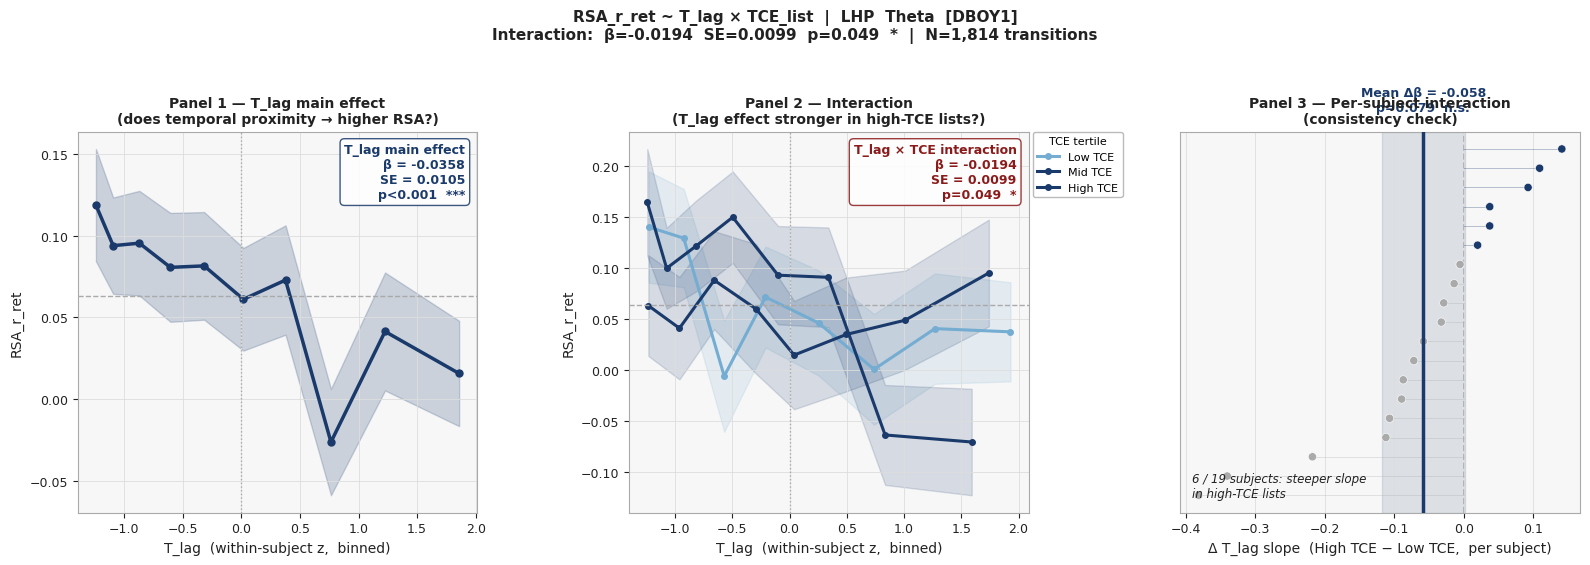


Figure saved: transition_lmm_tlag_tce/figure_transition_lmm.png

DONE



In [3]:
#!/usr/bin/env python3
"""
Single-stage transition-level LMM
==================================
RSA_r_ret ~ T_lag * TCE_list + (1 | subject / session / list)

Each row = one recall transition (word_i -> word_j) for one subject.
TCE_list = mean_T_clustering for that list, z-scored within subject.
T_lag    = temporal lag for that transition, z-scored within subject.

The interaction T_lag:TCE_list is the key term:
  "Do transitions with smaller T_lag show higher RSA,
   and is this effect stronger in lists with higher TCE?"

Random effects (nested):
  subject          — overall subject intercept
  subject/session  — session intercept within subject
  subject/session/list — list intercept within session

Outputs (./transition_lmm_tlag_tce/):
  transition_data_theta_lhp.csv   — merged transition-level table
  LMM_summary.txt                 — full statsmodels summary
  figure_transition_lmm.png       — 3-panel figure
"""

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from pathlib import Path
from statsmodels.regression.mixed_linear_model import MixedLM
warnings.filterwarnings('ignore')

# ── Config ─────────────────────────────────────────────────────────────────────
EXPERIMENT = 'DBOY1'
REGION     = 'LHP'
BAND       = 'theta'
OUTCOME    = 'RSA_r_ret'

RSA_CSV = Path(f'./rsa_lag_allregions/'
               f'ALL_SUBJECTS_{EXPERIMENT}_allregions_allbands_rsa_lag.csv')
TCE_CSV = Path('mean_temporal_clustering_per_list.csv')
OUT_DIR = Path('./transition_lmm_tlag_tce')
OUT_DIR.mkdir(exist_ok=True)

# ── Palette ────────────────────────────────────────────────────────────────────
COLOR       = '#1A3A6B'
COLOR_INT   = '#8B1A1A'   # interaction term
COLOR_NEG   = '#AAAAAA'
AX_COLOR    = '#F7F7F7'
GRID_COLOR  = '#DDDDDD'
SPINE_COLOR = '#AAAAAA'
TEXT_COLOR  = '#222222'

def style(ax):
    ax.set_facecolor(AX_COLOR)
    ax.grid(True, color=GRID_COLOR, lw=0.6, zorder=0)
    for sp in ax.spines.values():
        sp.set_edgecolor(SPINE_COLOR)
        sp.set_linewidth(0.8)
    ax.tick_params(colors=TEXT_COLOR, labelsize=9)
    ax.xaxis.label.set_color(TEXT_COLOR)
    ax.yaxis.label.set_color(TEXT_COLOR)
    ax.title.set_color(TEXT_COLOR)

def sig_stars(p):
    if not np.isfinite(p): return ''
    return ('***' if p < 0.001 else '**'  if p < 0.01 else
            '*'   if p < 0.05  else 'n.s.')

def p_str(p):
    if not np.isfinite(p): return 'p=NaN'
    return 'p<0.001' if p < 0.001 else f'p={p:.3f}'

# =============================================================================
# STEP 1 — Load RSA data (transition level)
# =============================================================================
print(f"\n{'='*65}")
print(f"Single-stage LMM  |  {REGION}  {BAND}  [{EXPERIMENT}]")
print(f"Model: {OUTCOME} ~ T_lag * TCE_list + random effects")
print(f"{'='*65}")

df = pd.read_csv(RSA_CSV)
df = df[(df['region'] == REGION) & (df['band'] == BAND)].copy()
df = df.rename(columns={'trial': 'list'})
df['subject'] = df['subject'].astype(str)

print(f"\nTransitions loaded: {len(df):,}  ({df['subject'].nunique()} subjects)")
print(f"Columns: {df.columns.tolist()}")

# =============================================================================
# STEP 2 — Merge list-level TCE
# =============================================================================
tce = pd.read_csv(TCE_CSV)
tce['subject'] = tce['subject'].astype(str)
tce = tce.rename(columns={'trial': 'list'})

# Attach TCE_list to every transition row
df = df.merge(
    tce[['subject', 'session', 'list', 'mean_T_clustering']],
    on=['subject', 'session', 'list'], how='inner'
)
print(f"After TCE merge: {len(df):,} transitions  "
      f"({df['subject'].nunique()} subjects)")

# Drop rows missing outcome, T_lag, or TCE
df = df.dropna(subset=[OUTCOME, 'T_lag', 'mean_T_clustering'])
print(f"After dropna:    {len(df):,} transitions")

# =============================================================================
# STEP 3 — Within-subject z-score T_lag and TCE_list
# =============================================================================
# Z-scoring within subject makes the betas interpretable as:
#   T_lag_z  : effect of T_lag at average TCE (main effect)
#   TCE_z    : effect of TCE at average T_lag (main effect)
#   T_lag_z:TCE_z : does the T_lag slope change with TCE? (interaction)

def zscore_within(x):
    s = x.std()
    return (x - x.mean()) / s if s > 0 else x * 0.0

df['T_lag_z'] = df.groupby('subject')['T_lag'].transform(zscore_within)
df['TCE_z']   = df.groupby('subject')['mean_T_clustering'].transform(zscore_within)

# Grouping variables for nested random effects
df['subj_sess']      = df['subject'] + '_' + df['session'].astype(str)
df['subj_sess_list'] = df['subj_sess'] + '_' + df['list'].astype(str)

# Save merged transition table
out_csv = OUT_DIR / f'transition_data_{BAND}_{REGION.lower()}.csv'
df.to_csv(out_csv, index=False)
print(f"\nSaved transition table: {out_csv.name}  ({len(df):,} rows)")

# =============================================================================
# STEP 4 — Fit LMM
#
# Model: RSA_r_ret ~ T_lag_z * TCE_z + random effects
#
# Random effects structure (nested):
#   groups     = subject          (top-level grouping)
#   vc_formula adds:
#     session within subject
#     list within session within subject
#
# This is the statsmodels way of specifying:
#   (1 | subject) + (1 | subject:session) + (1 | subject:session:list)
# =============================================================================
print(f"\nFitting LMM ...")
print(f"  Formula: {OUTCOME} ~ T_lag_z * TCE_z")
print(f"  Random:  (1|subject) + (1|subject:session) + (1|subject:session:list)")
print(f"  N transitions: {len(df):,}")
print(f"  N subjects:    {df['subject'].nunique()}")
print(f"  N sessions:    {df['subj_sess'].nunique()}")
print(f"  N lists:       {df['subj_sess_list'].nunique()}")

lmm_result = None
for method in ['lbfgs', 'nm', 'powell']:
    try:
        model = MixedLM.from_formula(
            f'{OUTCOME} ~ T_lag_z * TCE_z',
            data       = df,
            groups     = df['subject'],
            vc_formula = {
                'subj_sess':      '0 + C(subj_sess)',
                'subj_sess_list': '0 + C(subj_sess_list)',
            },
        )
        lmm_result = model.fit(reml=True, method=method)
        if np.isfinite(lmm_result.llf):
            print(f"  Converged ({method})  "
                  f"llf={lmm_result.llf:.2f}  AIC={lmm_result.aic:.2f}")
            break
    except Exception as e:
        print(f"  {method} failed: {e}")
        lmm_result = None

if lmm_result is None or not np.isfinite(lmm_result.llf):
    print("  WARNING: LMM did not converge.")
    raise RuntimeError("LMM failed — check data.")

# =============================================================================
# STEP 5 — Extract and print results
# =============================================================================
terms = {
    'Intercept':       'Intercept',
    'T_lag_z':         'T_lag  (main effect)',
    'TCE_z':           'TCE_list  (main effect)',
    'T_lag_z:TCE_z':   'T_lag × TCE_list  (interaction)',
}

print(f"\n{'='*65}")
print(f"LMM Results: {OUTCOME} ~ T_lag_z * TCE_z")
print(f"{'='*65}")
print(f"{'Term':<35} {'beta':>8} {'SE':>8} {'z':>7} {'p':>10} {'sig':>5}")
print(f"{'-'*65}")

results = {}
for col, label in terms.items():
    if col in lmm_result.params.index:
        b  = lmm_result.params[col]
        s  = lmm_result.bse[col]
        z  = lmm_result.tvalues[col]
        pv = lmm_result.pvalues[col]
        results[col] = dict(beta=b, se=s, z=z, p=pv, label=label)
        print(f"{label:<35} {b:>8.4f} {s:>8.4f} {z:>7.3f} "
              f"{pv:>10.4f} {sig_stars(pv):>5}")

print(f"{'-'*65}")
print(f"AIC={lmm_result.aic:.2f}  N={int(lmm_result.nobs):,} transitions")
print(f"{'='*65}")

# Save full summary
with open(OUT_DIR / 'LMM_summary.txt', 'w') as f:
    f.write(f"Model: {OUTCOME} ~ T_lag_z * TCE_z\n")
    f.write(f"Region: {REGION}  Band: {BAND}  Experiment: {EXPERIMENT}\n\n")
    f.write(str(lmm_result.summary()))
print(f"\nFull summary saved: LMM_summary.txt")

# =============================================================================
# FIGURE — 3-panel
# =============================================================================
fig = plt.figure(figsize=(16, 5.5))
fig.patch.set_facecolor('white')
axes = [fig.add_subplot(1, 3, i + 1) for i in range(3)]

# ── Panel 1: T_lag main effect
#    Mean RSA_r_ret by T_lag_z quintile  (collapsed across TCE)
# ──────────────────────────────────────────────────────────────
ax = axes[0]
style(ax)

df['tlag_bin'] = pd.qcut(df['T_lag_z'], q=10, labels=False, duplicates='drop')
bin_stats = (df.groupby('tlag_bin')[OUTCOME]
               .agg(['mean', 'sem', lambda x: df.loc[x.index, 'T_lag_z'].mean()])
               .reset_index())
bin_stats.columns = ['bin', 'mean', 'sem', 'x_center']

ax.fill_between(bin_stats['x_center'],
                bin_stats['mean'] - bin_stats['sem'],
                bin_stats['mean'] + bin_stats['sem'],
                color=COLOR, alpha=0.2)
ax.plot(bin_stats['x_center'], bin_stats['mean'],
        color=COLOR, lw=2.5, marker='o', ms=5)
ax.axhline(df[OUTCOME].mean(), color=SPINE_COLOR, lw=1, ls='--')
ax.axvline(0, color=SPINE_COLOR, lw=1, ls=':')

b_tlag = results.get('T_lag_z', {})
ax.text(0.97, 0.97,
        f"T_lag main effect\n"
        f"β = {b_tlag.get('beta', np.nan):.4f}\n"
        f"SE = {b_tlag.get('se', np.nan):.4f}\n"
        f"{p_str(b_tlag.get('p', np.nan))}  "
        f"{sig_stars(b_tlag.get('p', np.nan))}",
        transform=ax.transAxes, ha='right', va='top', fontsize=9,
        color=COLOR, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.35', fc='white',
                  ec=COLOR, alpha=0.85))

ax.set_xlabel('T_lag  (within-subject z,  binned)', fontsize=10)
ax.set_ylabel(OUTCOME, fontsize=10)
ax.set_title('Panel 1 — T_lag main effect\n(does temporal proximity → higher RSA?)',
             fontsize=10, fontweight='bold')

# ── Panel 2: Interaction — T_lag slope by TCE tertile
#    Split lists into low / mid / high TCE, plot RSA vs T_lag per group
# ──────────────────────────────────────────────────────────────────────
ax = axes[1]
style(ax)

df['tce_tertile'] = pd.qcut(df['TCE_z'], q=3, labels=['Low TCE', 'Mid TCE', 'High TCE'],
                              duplicates='drop')
tertile_colors = {'Low TCE': '#74ADD1', 'Mid TCE': COLOR, 'High TCE': '#1A3A6B'}

for tertile, tdf in df.groupby('tce_tertile', observed=True):
    tdf = tdf.copy()
    tdf['tlag_bin2'] = pd.qcut(tdf['T_lag_z'], q=8, labels=False,
                                duplicates='drop')
    bs = (tdf.groupby('tlag_bin2')[OUTCOME]
             .agg(['mean', 'sem',
                   lambda x: tdf.loc[x.index, 'T_lag_z'].mean()])
             .reset_index())
    bs.columns = ['bin', 'mean', 'sem', 'x_center']
    c = tertile_colors[str(tertile)]
    ax.fill_between(bs['x_center'],
                    bs['mean'] - bs['sem'],
                    bs['mean'] + bs['sem'],
                    color=c, alpha=0.15)
    ax.plot(bs['x_center'], bs['mean'],
            color=c, lw=2.2, marker='o', ms=4,
            label=str(tertile))

ax.axhline(df[OUTCOME].mean(), color=SPINE_COLOR, lw=1, ls='--')
ax.axvline(0, color=SPINE_COLOR, lw=1, ls=':')

b_int = results.get('T_lag_z:TCE_z', {})
ax.text(0.97, 0.97,
        f"T_lag × TCE interaction\n"
        f"β = {b_int.get('beta', np.nan):.4f}\n"
        f"SE = {b_int.get('se', np.nan):.4f}\n"
        f"{p_str(b_int.get('p', np.nan))}  "
        f"{sig_stars(b_int.get('p', np.nan))}",
        transform=ax.transAxes, ha='right', va='top', fontsize=9,
        color=COLOR_INT, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.35', fc='white',
                  ec=COLOR_INT, alpha=0.85))

ax.set_xlabel('T_lag  (within-subject z,  binned)', fontsize=10)
ax.set_ylabel(OUTCOME, fontsize=10)
ax.set_title('Panel 2 — Interaction\n(T_lag effect stronger in high-TCE lists?)',
             fontsize=10, fontweight='bold')
ax.legend(fontsize=8, facecolor='white', edgecolor=SPINE_COLOR,
          loc='upper left', bbox_to_anchor=(1.01, 1.0),
          borderaxespad=0, title='TCE tertile', title_fontsize=8)

# ── Panel 3: Per-subject interaction slopes (robustness check)
#    For each subject: OLS slope of RSA ~ T_lag_z separately
#    for low-TCE and high-TCE lists → ranked dot plot of difference
# ──────────────────────────────────────────────────────────────────
ax = axes[2]
style(ax)

subj_diffs = []
for subj, sg in df.groupby('subject'):
    sg = sg.dropna(subset=['T_lag_z', OUTCOME, 'tce_tertile'])
    lo = sg[sg['tce_tertile'] == 'Low TCE']
    hi = sg[sg['tce_tertile'] == 'High TCE']
    if len(lo) < 3 or len(hi) < 3:
        continue
    if lo['T_lag_z'].std() == 0 or hi['T_lag_z'].std() == 0:
        continue
    m_lo, _ = np.polyfit(lo['T_lag_z'].values, lo[OUTCOME].values, 1)
    m_hi, _ = np.polyfit(hi['T_lag_z'].values, hi[OUTCOME].values, 1)
    subj_diffs.append(m_hi - m_lo)   # positive = steeper slope in high-TCE lists

subj_diffs = np.array(subj_diffs)
n_sd       = len(subj_diffs)
order      = np.argsort(subj_diffs)
y_pos      = np.arange(n_sd)
ms_d       = subj_diffs.mean()
ci95_d     = 1.96 * subj_diffs.std() / np.sqrt(n_sd)
n_pos_d    = (subj_diffs > 0).sum()
from scipy.stats import ttest_1samp
t_d, p_d   = ttest_1samp(subj_diffs, 0)
p_d_str    = p_str(p_d)

dot_colors = [COLOR if s >= 0 else COLOR_NEG for s in subj_diffs[order]]
ax.scatter(subj_diffs[order], y_pos, c=dot_colors, s=35, zorder=3,
           edgecolors='white', linewidths=0.4)
for yi, si, dc in zip(y_pos, subj_diffs[order], dot_colors):
    ax.plot([0, si], [yi, yi], color=dc, alpha=0.3, lw=0.7, zorder=2)

ax.axvline(0, color=SPINE_COLOR, lw=1.2, ls='--', zorder=1)
ax.axvspan(ms_d - ci95_d, ms_d + ci95_d, color=COLOR, alpha=0.12, zorder=0)
ax.axvline(ms_d, color=COLOR, lw=2.5, zorder=4)
ax.text(ms_d, n_sd + 0.8,
        f'Mean Δβ = {ms_d:.3f}\n{p_d_str}  {sig_stars(p_d)}',
        ha='center', va='bottom', color=COLOR,
        fontsize=9, fontweight='bold')
ax.text(0.03, 0.04,
        f'{n_pos_d} / {n_sd} subjects: steeper slope\nin high-TCE lists',
        transform=ax.transAxes, fontsize=8.5,
        color=TEXT_COLOR, style='italic')

ax.set_yticks([])
ax.set_xlabel('Δ T_lag slope  (High TCE − Low TCE,  per subject)', fontsize=10)
ax.set_title('Panel 3 — Per-subject interaction\n(consistency check)',
             fontsize=10, fontweight='bold')

# ── Super-title ────────────────────────────────────────────────────────────────
b_int_val = results.get('T_lag_z:TCE_z', {})
fig.suptitle(
    f'{OUTCOME} ~ T_lag × TCE_list  |  {REGION}  {BAND.capitalize()}  [{EXPERIMENT}]\n'
    f'Interaction:  β={b_int_val.get("beta", np.nan):.4f}  '
    f'SE={b_int_val.get("se", np.nan):.4f}  '
    f'{p_str(b_int_val.get("p", np.nan))}  '
    f'{sig_stars(b_int_val.get("p", np.nan))}  '
    f'|  N={int(lmm_result.nobs):,} transitions',
    fontsize=11, fontweight='bold', y=1.02, color=TEXT_COLOR)

# Leave extra room on the right of Panel 2 for the outside legend
plt.tight_layout()
plt.subplots_adjust(wspace=0.38)   # a bit more horizontal space between panels
fig_path = OUT_DIR / 'figure_transition_lmm.png'
fig.savefig(fig_path, dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print(f"\nFigure saved: {fig_path}")
print(f"\n{'='*65}")
print("DONE")
print(f"{'='*65}\n")

Transitions: 1,814  |  Subjects: 27

T_lag summary:
  Min    = 1.0
  Max    = 11.0
  Mean   = 4.538
  Median = 4.000
  SD     = 2.924

Unique T_lag values: [ 1  2  3  4  5  6  7  8  9 10 11]


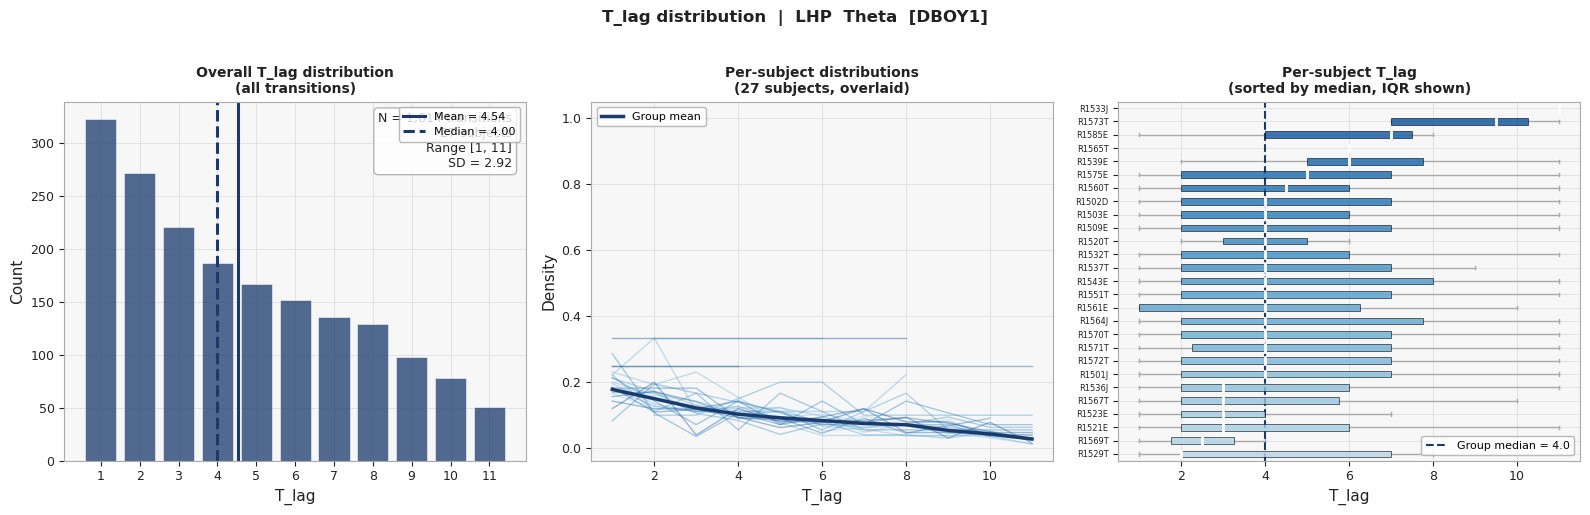


Figure saved: withinlist_tlag_rsa_simple/tlag_distribution.png


In [4]:
#!/usr/bin/env python3
"""
Distribution of T_lag
=====================
Quick diagnostic plot showing:
  Panel 1 — histogram of raw T_lag values (all transitions)
  Panel 2 — histogram per subject (overlaid, semi-transparent)
  Panel 3 — box plot by subject (sorted by median)
"""

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
warnings.filterwarnings('ignore')

# ── Config ─────────────────────────────────────────────────────────────────────
EXPERIMENT = 'DBOY1'
REGION     = 'LHP'
BAND       = 'theta'

RSA_CSV = Path(f'./rsa_lag_allregions/'
               f'ALL_SUBJECTS_{EXPERIMENT}_allregions_allbands_rsa_lag.csv')
OUT_DIR = Path('./withinlist_tlag_rsa_simple')
OUT_DIR.mkdir(exist_ok=True)

# ── Palette ────────────────────────────────────────────────────────────────────
COLOR       = '#1A3A6B'
AX_COLOR    = '#F7F7F7'
GRID_COLOR  = '#DDDDDD'
SPINE_COLOR = '#AAAAAA'
TEXT_COLOR  = '#222222'

def style(ax):
    ax.set_facecolor(AX_COLOR)
    ax.grid(True, color=GRID_COLOR, lw=0.6, zorder=0)
    for sp in ax.spines.values():
        sp.set_edgecolor(SPINE_COLOR)
        sp.set_linewidth(0.8)
    ax.tick_params(colors=TEXT_COLOR, labelsize=9)
    ax.xaxis.label.set_color(TEXT_COLOR)
    ax.yaxis.label.set_color(TEXT_COLOR)
    ax.title.set_color(TEXT_COLOR)

# ── Load ───────────────────────────────────────────────────────────────────────
df = pd.read_csv(RSA_CSV)
df = df[(df['region'] == REGION) & (df['band'] == BAND)].copy()
df = df.rename(columns={'trial': 'list'})
df = df.dropna(subset=['T_lag'])
df['subject'] = df['subject'].astype(str)

t_all     = df['T_lag'].values
subjects  = sorted(df['subject'].unique())
n_subj    = len(subjects)

print(f"Transitions: {len(df):,}  |  Subjects: {n_subj}")
print(f"\nT_lag summary:")
print(f"  Min    = {t_all.min():.1f}")
print(f"  Max    = {t_all.max():.1f}")
print(f"  Mean   = {t_all.mean():.3f}")
print(f"  Median = {np.median(t_all):.3f}")
print(f"  SD     = {t_all.std():.3f}")
print(f"\nUnique T_lag values: {np.sort(np.unique(t_all))}")

# ── Figure ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor('white')

# ── Panel 1: overall histogram ────────────────────────────────────────────────
ax = axes[0]
style(ax)

unique_vals = np.sort(np.unique(t_all))
if len(unique_vals) <= 30:
    # discrete — one bar per value
    counts = pd.Series(t_all).value_counts().sort_index()
    ax.bar(counts.index, counts.values,
           color=COLOR, alpha=0.75, edgecolor='white',
           linewidth=0.5, width=0.8, zorder=2)
    ax.set_xticks(unique_vals)
else:
    ax.hist(t_all, bins=40, color=COLOR, alpha=0.75,
            edgecolor='white', linewidth=0.4, zorder=2)

ax.axvline(t_all.mean(),   color=COLOR,       lw=2.2, ls='-',
           label=f'Mean = {t_all.mean():.2f}')
ax.axvline(np.median(t_all), color=COLOR,     lw=2.2, ls='--',
           label=f'Median = {np.median(t_all):.2f}')

ax.text(0.97, 0.97,
        f'N = {len(t_all):,} transitions\n'
        f'{n_subj} subjects\n'
        f'Range [{t_all.min():.0f}, {t_all.max():.0f}]\n'
        f'SD = {t_all.std():.2f}',
        transform=ax.transAxes, ha='right', va='top', fontsize=9,
        color=TEXT_COLOR,
        bbox=dict(boxstyle='round,pad=0.35', fc='white',
                  ec=SPINE_COLOR, alpha=0.85))

ax.set_xlabel('T_lag', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.set_title('Overall T_lag distribution\n(all transitions)', fontsize=10, fontweight='bold')
ax.legend(fontsize=8, facecolor='white', edgecolor=SPINE_COLOR)

# ── Panel 2: per-subject overlaid histograms ─────────────────────────────────
ax = axes[1]
style(ax)

cmap   = plt.cm.Blues
colors = [cmap(0.35 + 0.55 * i / max(n_subj - 1, 1)) for i in range(n_subj)]

for i, subj in enumerate(subjects):
    vals = df[df['subject'] == subj]['T_lag'].values
    if len(unique_vals) <= 30:
        counts_s = pd.Series(vals).value_counts().sort_index()
        # normalise to density
        ax.plot(counts_s.index,
                counts_s.values / counts_s.values.sum(),
                color=colors[i], alpha=0.4, lw=1.0)
    else:
        ax.hist(vals, bins=25, density=True,
                color=colors[i], alpha=0.25,
                edgecolor='none', zorder=2)

# group mean density on top
if len(unique_vals) <= 30:
    overall_counts = pd.Series(t_all).value_counts().sort_index()
    overall_density = overall_counts / overall_counts.sum()
    ax.plot(overall_density.index, overall_density.values,
            color=COLOR, lw=2.5, zorder=5, label='Group mean')
else:
    ax.hist(t_all, bins=25, density=True,
            color=COLOR, alpha=0.0, edgecolor='none')
    # kernel density estimate for the group
    from scipy.stats import gaussian_kde
    kde = gaussian_kde(t_all, bw_method=0.3)
    x_kde = np.linspace(t_all.min(), t_all.max(), 300)
    ax.plot(x_kde, kde(x_kde), color=COLOR, lw=2.5, zorder=5,
            label='Group KDE')

ax.set_xlabel('T_lag', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title(f'Per-subject distributions\n({n_subj} subjects, overlaid)',
             fontsize=10, fontweight='bold')
ax.legend(fontsize=8, facecolor='white', edgecolor=SPINE_COLOR)

# ── Panel 3: per-subject box plot sorted by median ───────────────────────────
ax = axes[2]
style(ax)

subj_data   = [df[df['subject'] == s]['T_lag'].values for s in subjects]
subj_medians = [np.median(d) for d in subj_data]
order        = np.argsort(subj_medians)

sorted_data    = [subj_data[i] for i in order]
sorted_subjects = [subjects[i] for i in order]

bp = ax.boxplot(sorted_data,
                vert=False,
                patch_artist=True,
                showfliers=False,
                medianprops=dict(color='white', lw=2),
                whiskerprops=dict(color=SPINE_COLOR, lw=1),
                capprops=dict(color=SPINE_COLOR, lw=1),
                boxprops=dict(linewidth=0.5))

cmap2  = plt.cm.Blues
for i, patch in enumerate(bp['boxes']):
    patch.set_facecolor(cmap2(0.3 + 0.6 * i / max(n_subj - 1, 1)))
    patch.set_alpha(0.8)

ax.axvline(np.median(t_all), color=COLOR, lw=1.5,
           ls='--', label=f'Group median = {np.median(t_all):.1f}')
ax.set_yticks(range(1, n_subj + 1))
ax.set_yticklabels(sorted_subjects, fontsize=6)
ax.set_xlabel('T_lag', fontsize=11)
ax.set_title('Per-subject T_lag\n(sorted by median, IQR shown)',
             fontsize=10, fontweight='bold')
ax.legend(fontsize=8, facecolor='white', edgecolor=SPINE_COLOR,
          loc='lower right')

# ── Super-title ────────────────────────────────────────────────────────────────
fig.suptitle(
    f'T_lag distribution  |  {REGION}  {BAND.capitalize()}  [{EXPERIMENT}]',
    fontsize=12, fontweight='bold', y=1.02, color=TEXT_COLOR)

plt.tight_layout()
fig_path = OUT_DIR / 'tlag_distribution.png'
fig.savefig(fig_path, dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print(f"\nFigure saved: {fig_path}")


Single-stage LMM (raw scale)  |  LHP  theta  [DBOY1]
Model: RSA_r_ret ~ T_lag * TCE_list  (no z-scoring)

Transitions loaded: 1,814  (27 subjects)
After TCE merge + dropna: 1,814 transitions  (27 subjects)

T_lag summary:  min=1.0  max=11.0  mean=4.538
TCE summary:    min=0.000  max=1.000  mean=0.590
RSA summary:    min=-1.000  max=1.000  mean=0.063

Saved: transition_data_theta_lhp_raw.csv

Fitting LMM (raw scale) ...
  N transitions : 1,814
  N subjects    : 27
  N sessions    : 58
  N lists       : 171
  Converged (lbfgs)  llf=-1095.37  AIC=nan

LMM Results: RSA_r_ret ~ T_lag * mean_T_clustering  [raw scale]
Term                                           beta         SE        z          p   sig
-----------------------------------------------------------------
Intercept                                  -0.01218    0.07872   -0.155     0.8770  n.s.
T_lag  (main effect)                        0.00844    0.01265    0.667     0.5046  n.s.
TCE_list  (main effect)                     0.2

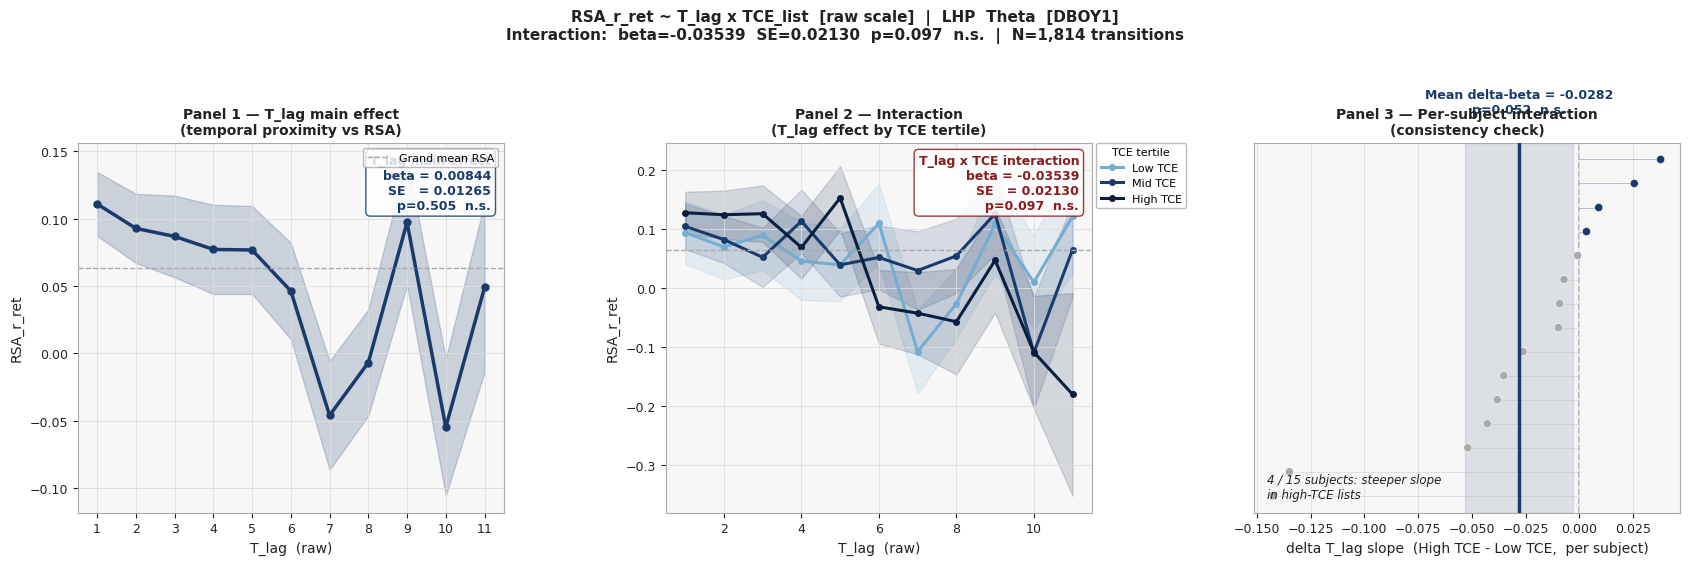


Figure saved: transition_lmm_tlag_tce_raw/figure_transition_lmm_raw.png

DONE



In [5]:
#!/usr/bin/env python3
"""
Single-stage transition-level LMM  (raw scale, no z-scoring)
==============================================================
RSA_r_ret ~ T_lag * TCE_list + (1 | subject / session / list)

T_lag    = raw temporal lag (serial position difference)
TCE_list = raw mean_T_clustering for that list (no standardisation)

Outputs (./transition_lmm_tlag_tce_raw/):
  transition_data_theta_lhp_raw.csv
  LMM_summary_raw.txt
  figure_transition_lmm_raw.png
"""

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_1samp
from pathlib import Path
from statsmodels.regression.mixed_linear_model import MixedLM
warnings.filterwarnings('ignore')

# ── Config ─────────────────────────────────────────────────────────────────────
EXPERIMENT = 'DBOY1'
REGION     = 'LHP'
BAND       = 'theta'
OUTCOME    = 'RSA_r_ret'

RSA_CSV = Path(f'./rsa_lag_allregions/'
               f'ALL_SUBJECTS_{EXPERIMENT}_allregions_allbands_rsa_lag.csv')
TCE_CSV = Path('mean_temporal_clustering_per_list.csv')
OUT_DIR = Path('./transition_lmm_tlag_tce_raw')
OUT_DIR.mkdir(exist_ok=True)

# ── Palette ────────────────────────────────────────────────────────────────────
COLOR       = '#1A3A6B'
COLOR_INT   = '#8B1A1A'
COLOR_NEG   = '#AAAAAA'
AX_COLOR    = '#F7F7F7'
GRID_COLOR  = '#DDDDDD'
SPINE_COLOR = '#AAAAAA'
TEXT_COLOR  = '#222222'

def style(ax):
    ax.set_facecolor(AX_COLOR)
    ax.grid(True, color=GRID_COLOR, lw=0.6, zorder=0)
    for sp in ax.spines.values():
        sp.set_edgecolor(SPINE_COLOR)
        sp.set_linewidth(0.8)
    ax.tick_params(colors=TEXT_COLOR, labelsize=9)
    ax.xaxis.label.set_color(TEXT_COLOR)
    ax.yaxis.label.set_color(TEXT_COLOR)
    ax.title.set_color(TEXT_COLOR)

def sig_stars(p):
    if not np.isfinite(p): return ''
    return ('***' if p < 0.001 else '**' if p < 0.01 else
            '*'   if p < 0.05  else 'n.s.')

def fmt_p(p):
    if not np.isfinite(p): return 'p=NaN'
    return 'p<0.001' if p < 0.001 else f'p={p:.3f}'

# =============================================================================
# STEP 1 — Load RSA data
# =============================================================================
print(f"\n{'='*65}")
print(f"Single-stage LMM (raw scale)  |  {REGION}  {BAND}  [{EXPERIMENT}]")
print(f"Model: {OUTCOME} ~ T_lag * TCE_list  (no z-scoring)")
print(f"{'='*65}")

df = pd.read_csv(RSA_CSV)
df = df[(df['region'] == REGION) & (df['band'] == BAND)].copy()
df = df.rename(columns={'trial': 'list'})
df['subject'] = df['subject'].astype(str)
print(f"\nTransitions loaded: {len(df):,}  ({df['subject'].nunique()} subjects)")

# =============================================================================
# STEP 2 — Merge list-level TCE (raw values, no transformation)
# =============================================================================
tce = pd.read_csv(TCE_CSV)
tce['subject'] = tce['subject'].astype(str)
tce = tce.rename(columns={'trial': 'list'})

df = df.merge(
    tce[['subject', 'session', 'list', 'mean_T_clustering']],
    on=['subject', 'session', 'list'], how='inner'
)
df = df.dropna(subset=[OUTCOME, 'T_lag', 'mean_T_clustering'])

print(f"After TCE merge + dropna: {len(df):,} transitions  "
      f"({df['subject'].nunique()} subjects)")
print(f"\nT_lag summary:  min={df['T_lag'].min():.1f}  "
      f"max={df['T_lag'].max():.1f}  mean={df['T_lag'].mean():.3f}")
print(f"TCE summary:    min={df['mean_T_clustering'].min():.3f}  "
      f"max={df['mean_T_clustering'].max():.3f}  "
      f"mean={df['mean_T_clustering'].mean():.3f}")
print(f"RSA summary:    min={df[OUTCOME].min():.3f}  "
      f"max={df[OUTCOME].max():.3f}  mean={df[OUTCOME].mean():.3f}")

# =============================================================================
# STEP 3 — Build nested grouping variables
# =============================================================================
df['subj_sess']      = df['subject'] + '_' + df['session'].astype(str)
df['subj_sess_list'] = df['subj_sess'] + '_' + df['list'].astype(str)

# Save merged table
out_csv = OUT_DIR / f'transition_data_{BAND}_{REGION.lower()}_raw.csv'
df.to_csv(out_csv, index=False)
print(f"\nSaved: {out_csv.name}")

# =============================================================================
# STEP 4 — Fit LMM on raw scale
#
# RSA_r_ret ~ T_lag * mean_T_clustering
#           + (1|subject) + (1|subject:session) + (1|subject:session:list)
# =============================================================================
print(f"\nFitting LMM (raw scale) ...")
print(f"  N transitions : {len(df):,}")
print(f"  N subjects    : {df['subject'].nunique()}")
print(f"  N sessions    : {df['subj_sess'].nunique()}")
print(f"  N lists       : {df['subj_sess_list'].nunique()}")

lmm_result = None
for method in ['lbfgs', 'nm', 'powell']:
    try:
        model = MixedLM.from_formula(
            f'{OUTCOME} ~ T_lag * mean_T_clustering',
            data       = df,
            groups     = df['subject'],
            vc_formula = {
                'subj_sess':      '0 + C(subj_sess)',
                'subj_sess_list': '0 + C(subj_sess_list)',
            },
        )
        lmm_result = model.fit(reml=True, method=method)
        if np.isfinite(lmm_result.llf):
            print(f"  Converged ({method})  "
                  f"llf={lmm_result.llf:.2f}  AIC={lmm_result.aic:.2f}")
            break
    except Exception as e:
        print(f"  {method} failed: {e}")
        lmm_result = None

if lmm_result is None or not np.isfinite(lmm_result.llf):
    raise RuntimeError("LMM failed to converge — check data.")

# =============================================================================
# STEP 5 — Extract results
# =============================================================================
terms = {
    'Intercept':                     'Intercept',
    'T_lag':                         'T_lag  (main effect)',
    'mean_T_clustering':             'TCE_list  (main effect)',
    'T_lag:mean_T_clustering':       'T_lag x TCE_list  (interaction)',
}

print(f"\n{'='*65}")
print(f"LMM Results: {OUTCOME} ~ T_lag * mean_T_clustering  [raw scale]")
print(f"{'='*65}")
print(f"{'Term':<40} {'beta':>10} {'SE':>10} {'z':>8} {'p':>10} {'sig':>5}")
print(f"{'-'*65}")

results = {}
for col, label in terms.items():
    if col in lmm_result.params.index:
        b  = lmm_result.params[col]
        s  = lmm_result.bse[col]
        z  = lmm_result.tvalues[col]
        pv = lmm_result.pvalues[col]
        results[col] = dict(beta=b, se=s, z=z, p=pv, label=label)
        print(f"{label:<40} {b:>10.5f} {s:>10.5f} {z:>8.3f} "
              f"{pv:>10.4f} {sig_stars(pv):>5}")

print(f"{'-'*65}")
print(f"AIC={lmm_result.aic:.2f}  N={int(lmm_result.nobs):,} transitions")
print(f"{'='*65}")

with open(OUT_DIR / 'LMM_summary_raw.txt', 'w') as f:
    f.write(f"Model: {OUTCOME} ~ T_lag * mean_T_clustering  [raw scale]\n")
    f.write(f"Region: {REGION}  Band: {BAND}  Experiment: {EXPERIMENT}\n\n")
    f.write(str(lmm_result.summary()))
print(f"\nFull summary saved: LMM_summary_raw.txt")

# =============================================================================
# FIGURE — 3-panel
# =============================================================================
fig = plt.figure(figsize=(17, 5.5))
fig.patch.set_facecolor('white')
axes = [fig.add_subplot(1, 3, i + 1) for i in range(3)]

# ── Panel 1: T_lag main effect
#    Mean RSA by T_lag value (raw bins)
# ─────────────────────────────────────
ax = axes[0]
style(ax)

unique_tlags = np.sort(df['T_lag'].unique())
if len(unique_tlags) <= 25:
    # discrete — one point per T_lag value
    grp = df.groupby('T_lag')[OUTCOME].agg(['mean', 'sem']).reset_index()
    ax.fill_between(grp['T_lag'],
                    grp['mean'] - grp['sem'],
                    grp['mean'] + grp['sem'],
                    color=COLOR, alpha=0.2)
    ax.plot(grp['T_lag'], grp['mean'],
            color=COLOR, lw=2.5, marker='o', ms=5)
    ax.set_xticks(unique_tlags)
else:
    df['tlag_bin'] = pd.qcut(df['T_lag'], q=12, labels=False, duplicates='drop')
    grp = (df.groupby('tlag_bin')[OUTCOME]
             .agg(['mean', 'sem',
                   lambda x: df.loc[x.index, 'T_lag'].mean()])
             .reset_index())
    grp.columns = ['bin', 'mean', 'sem', 'x_center']
    ax.fill_between(grp['x_center'],
                    grp['mean'] - grp['sem'],
                    grp['mean'] + grp['sem'],
                    color=COLOR, alpha=0.2)
    ax.plot(grp['x_center'], grp['mean'],
            color=COLOR, lw=2.5, marker='o', ms=5)

ax.axhline(df[OUTCOME].mean(), color=SPINE_COLOR, lw=1, ls='--',
           label='Grand mean RSA')

b_tlag = results.get('T_lag', {})
ax.text(0.97, 0.97,
        f"T_lag main effect\n"
        f"beta = {b_tlag.get('beta', np.nan):.5f}\n"
        f"SE   = {b_tlag.get('se',   np.nan):.5f}\n"
        f"{fmt_p(b_tlag.get('p', np.nan))}  "
        f"{sig_stars(b_tlag.get('p', np.nan))}",
        transform=ax.transAxes, ha='right', va='top', fontsize=9,
        color=COLOR, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.35', fc='white',
                  ec=COLOR, alpha=0.85))

ax.set_xlabel('T_lag  (raw)', fontsize=10)
ax.set_ylabel(OUTCOME, fontsize=10)
ax.set_title('Panel 1 — T_lag main effect\n(temporal proximity vs RSA)',
             fontsize=10, fontweight='bold')
ax.legend(fontsize=8, facecolor='white', edgecolor=SPINE_COLOR)

# ── Panel 2: Interaction
#    RSA vs T_lag separately for low / mid / high TCE tertile
# ─────────────────────────────────────────────────────────────
ax = axes[1]
style(ax)

df['tce_tertile'] = pd.qcut(df['mean_T_clustering'], q=3,
                              labels=['Low TCE', 'Mid TCE', 'High TCE'],
                              duplicates='drop')
tertile_colors = {
    'Low TCE':  '#74ADD1',
    'Mid TCE':  COLOR,
    'High TCE': '#0A1F40',
}

for tertile, tdf in df.groupby('tce_tertile', observed=True):
    tdf = tdf.copy()
    uniq = np.sort(tdf['T_lag'].unique())
    if len(uniq) <= 25:
        bs = tdf.groupby('T_lag')[OUTCOME].agg(['mean', 'sem']).reset_index()
        bs.columns = ['x_center', 'mean', 'sem']
    else:
        tdf['tlag_bin2'] = pd.qcut(tdf['T_lag'], q=8, labels=False,
                                    duplicates='drop')
        bs = (tdf.groupby('tlag_bin2')[OUTCOME]
                 .agg(['mean', 'sem',
                       lambda x: tdf.loc[x.index, 'T_lag'].mean()])
                 .reset_index())
        bs.columns = ['bin', 'mean', 'sem', 'x_center']

    c = tertile_colors[str(tertile)]
    ax.fill_between(bs['x_center'],
                    bs['mean'] - bs['sem'],
                    bs['mean'] + bs['sem'],
                    color=c, alpha=0.15)
    ax.plot(bs['x_center'], bs['mean'],
            color=c, lw=2.2, marker='o', ms=4, label=str(tertile))

ax.axhline(df[OUTCOME].mean(), color=SPINE_COLOR, lw=1, ls='--')

b_int = results.get('T_lag:mean_T_clustering', {})
ax.text(0.97, 0.97,
        f"T_lag x TCE interaction\n"
        f"beta = {b_int.get('beta', np.nan):.5f}\n"
        f"SE   = {b_int.get('se',   np.nan):.5f}\n"
        f"{fmt_p(b_int.get('p', np.nan))}  "
        f"{sig_stars(b_int.get('p', np.nan))}",
        transform=ax.transAxes, ha='right', va='top', fontsize=9,
        color=COLOR_INT, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.35', fc='white',
                  ec=COLOR_INT, alpha=0.85))

ax.set_xlabel('T_lag  (raw)', fontsize=10)
ax.set_ylabel(OUTCOME, fontsize=10)
ax.set_title('Panel 2 — Interaction\n(T_lag effect by TCE tertile)',
             fontsize=10, fontweight='bold')
ax.legend(fontsize=8, facecolor='white', edgecolor=SPINE_COLOR,
          loc='upper left', bbox_to_anchor=(1.01, 1.0),
          borderaxespad=0, title='TCE tertile', title_fontsize=8)

# ── Panel 3: Per-subject OLS slope difference (high - low TCE)
# ─────────────────────────────────────────────────────────────
ax = axes[2]
style(ax)

subj_diffs = []
for subj, sg in df.groupby('subject'):
    sg = sg.dropna(subset=['T_lag', OUTCOME, 'tce_tertile'])
    lo = sg[sg['tce_tertile'] == 'Low TCE']
    hi = sg[sg['tce_tertile'] == 'High TCE']
    if len(lo) < 3 or len(hi) < 3:
        continue
    if lo['T_lag'].std() == 0 or hi['T_lag'].std() == 0:
        continue
    m_lo, _ = np.polyfit(lo['T_lag'].values, lo[OUTCOME].values, 1)
    m_hi, _ = np.polyfit(hi['T_lag'].values, hi[OUTCOME].values, 1)
    subj_diffs.append(m_hi - m_lo)

subj_diffs = np.array(subj_diffs)
n_sd       = len(subj_diffs)
order      = np.argsort(subj_diffs)
y_pos      = np.arange(n_sd)
ms_d       = subj_diffs.mean()
ci95_d     = 1.96 * subj_diffs.std() / np.sqrt(n_sd)
n_pos_d    = (subj_diffs > 0).sum()
t_d, p_d   = ttest_1samp(subj_diffs, 0)

dot_colors = [COLOR if s >= 0 else COLOR_NEG for s in subj_diffs[order]]
ax.scatter(subj_diffs[order], y_pos, c=dot_colors, s=35, zorder=3,
           edgecolors='white', linewidths=0.4)
for yi, si, dc in zip(y_pos, subj_diffs[order], dot_colors):
    ax.plot([0, si], [yi, yi], color=dc, alpha=0.3, lw=0.7, zorder=2)

ax.axvline(0,    color=SPINE_COLOR, lw=1.2, ls='--', zorder=1)
ax.axvspan(ms_d - ci95_d, ms_d + ci95_d, color=COLOR, alpha=0.12, zorder=0)
ax.axvline(ms_d, color=COLOR, lw=2.5, zorder=4)
ax.text(ms_d, n_sd + 0.8,
        f'Mean delta-beta = {ms_d:.4f}\n{fmt_p(p_d)}  {sig_stars(p_d)}',
        ha='center', va='bottom', color=COLOR, fontsize=9, fontweight='bold')
ax.text(0.03, 0.04,
        f'{n_pos_d} / {n_sd} subjects: steeper slope\nin high-TCE lists',
        transform=ax.transAxes, fontsize=8.5,
        color=TEXT_COLOR, style='italic')

ax.set_yticks([])
ax.set_xlabel('delta T_lag slope  (High TCE - Low TCE,  per subject)', fontsize=10)
ax.set_title('Panel 3 — Per-subject interaction\n(consistency check)',
             fontsize=10, fontweight='bold')

# ── Super-title ────────────────────────────────────────────────────────────────
b_int_val = results.get('T_lag:mean_T_clustering', {})
fig.suptitle(
    f'{OUTCOME} ~ T_lag x TCE_list  [raw scale]  |  '
    f'{REGION}  {BAND.capitalize()}  [{EXPERIMENT}]\n'
    f'Interaction:  beta={b_int_val.get("beta", np.nan):.5f}  '
    f'SE={b_int_val.get("se", np.nan):.5f}  '
    f'{fmt_p(b_int_val.get("p", np.nan))}  '
    f'{sig_stars(b_int_val.get("p", np.nan))}  '
    f'|  N={int(lmm_result.nobs):,} transitions',
    fontsize=11, fontweight='bold', y=1.02, color=TEXT_COLOR)

plt.tight_layout()
plt.subplots_adjust(wspace=0.38)
fig_path = OUT_DIR / 'figure_transition_lmm_raw.png'
fig.savefig(fig_path, dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print(f"\nFigure saved: {fig_path}")
print(f"\n{'='*65}")
print("DONE")
print(f"{'='*65}\n")


Single-stage LMM (z-scored)  |  LHP  theta  [DBOY1]
Model: RSA_r_ret ~ T_lag_z * TCE_z + random effects

Transitions loaded: 1,814  (27 subjects)
After TCE merge + dropna: 1,814 transitions  (27 subjects)
Saved: transition_data_theta_lhp_z.csv

Fitting LMM ...
  N transitions : 1,814
  N subjects    : 27
  N sessions    : 58
  N lists       : 171
  Converged (lbfgs)  llf=-1097.19  AIC=nan

LMM Results: RSA_r_ret ~ T_lag_z * TCE_z
Term                                          beta        SE        z          p   sig
-----------------------------------------------------------------
Intercept                                   0.0564    0.0153    3.674     0.0002   ***
T_lag_z  (main effect)                     -0.0358    0.0105   -3.400     0.0007   ***
TCE_z  (main effect)                       -0.0031    0.0129   -0.238     0.8117  n.s.
T_lag_z x TCE_z  (interaction)             -0.0194    0.0099   -1.967     0.0491     *
----------------------------------------------------------------

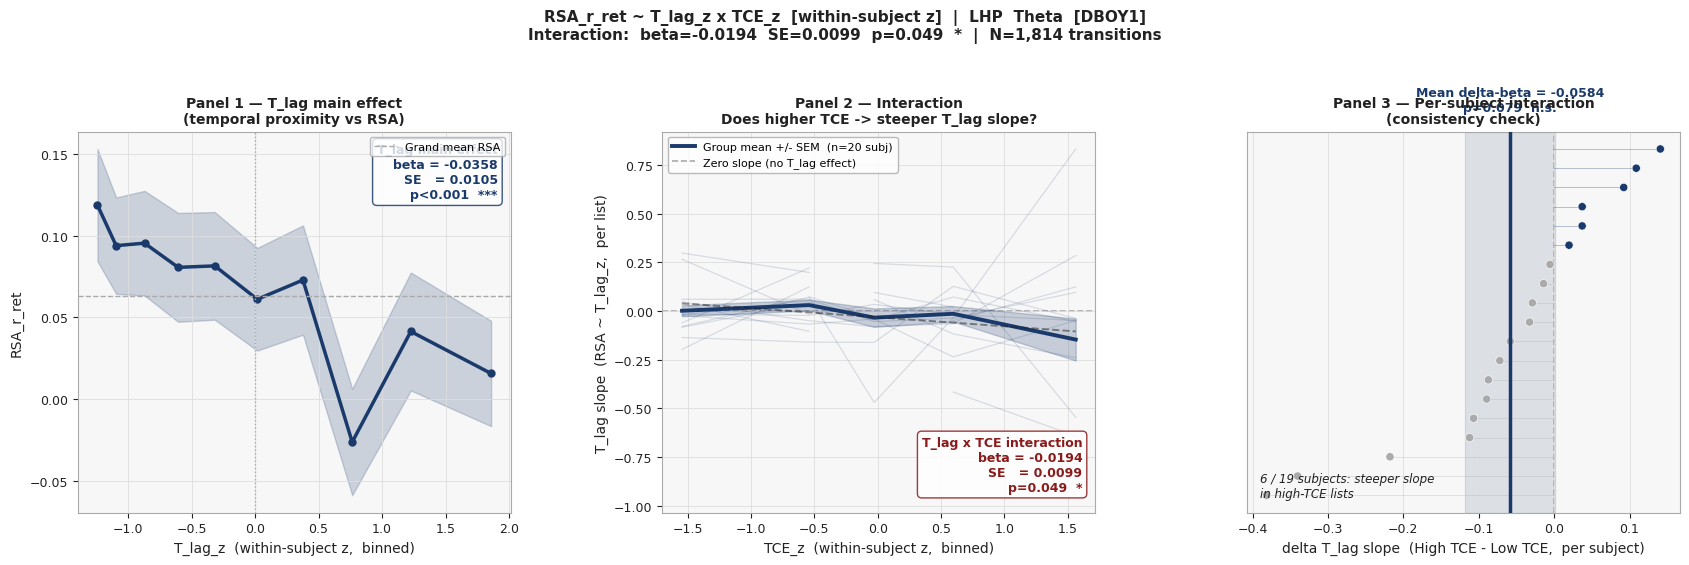


Figure saved: transition_lmm_tlag_tce_zscore/figure_transition_lmm_z.png

DONE



In [8]:
#!/usr/bin/env python3
"""
Single-stage transition-level LMM  (within-subject z-scored)
=============================================================
RSA_r_ret ~ T_lag_z * TCE_z + (1 | subject / session / list)

T_lag_z  = T_lag z-scored within subject
TCE_z    = mean_T_clustering z-scored within subject

Panel 2 (interaction plot):
  X = TCE score (binned), Y = per-list OLS slope of RSA ~ T_lag_z
  One faint line per subject, bold group mean +/- SEM

Outputs (./transition_lmm_tlag_tce_zscore/):
  transition_data_theta_lhp_z.csv
  LMM_summary_z.txt
  figure_transition_lmm_z.png
"""

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_1samp
from pathlib import Path
from statsmodels.regression.mixed_linear_model import MixedLM
warnings.filterwarnings('ignore')

# ── Config ─────────────────────────────────────────────────────────────────────
EXPERIMENT = 'DBOY1'
REGION     = 'LHP'
BAND       = 'theta'
OUTCOME    = 'RSA_r_ret'

RSA_CSV = Path(f'./rsa_lag_allregions/'
               f'ALL_SUBJECTS_{EXPERIMENT}_allregions_allbands_rsa_lag.csv')
TCE_CSV = Path('mean_temporal_clustering_per_list.csv')
OUT_DIR = Path('./transition_lmm_tlag_tce_zscore')
OUT_DIR.mkdir(exist_ok=True)

# ── Palette ────────────────────────────────────────────────────────────────────
COLOR       = '#1A3A6B'
COLOR_INT   = '#8B1A1A'
COLOR_NEG   = '#AAAAAA'
AX_COLOR    = '#F7F7F7'
GRID_COLOR  = '#DDDDDD'
SPINE_COLOR = '#AAAAAA'
TEXT_COLOR  = '#222222'

def style(ax):
    ax.set_facecolor(AX_COLOR)
    ax.grid(True, color=GRID_COLOR, lw=0.6, zorder=0)
    for sp in ax.spines.values():
        sp.set_edgecolor(SPINE_COLOR)
        sp.set_linewidth(0.8)
    ax.tick_params(colors=TEXT_COLOR, labelsize=9)
    ax.xaxis.label.set_color(TEXT_COLOR)
    ax.yaxis.label.set_color(TEXT_COLOR)
    ax.title.set_color(TEXT_COLOR)

def sig_stars(p):
    if not np.isfinite(p): return ''
    return ('***' if p < 0.001 else '**' if p < 0.01 else
            '*'   if p < 0.05  else 'n.s.')

def fmt_p(p):
    if not np.isfinite(p): return 'p=NaN'
    return 'p<0.001' if p < 0.001 else f'p={p:.3f}'

# =============================================================================
# STEP 1 — Load RSA data
# =============================================================================
print(f"\n{'='*65}")
print(f"Single-stage LMM (z-scored)  |  {REGION}  {BAND}  [{EXPERIMENT}]")
print(f"Model: {OUTCOME} ~ T_lag_z * TCE_z + random effects")
print(f"{'='*65}")

df = pd.read_csv(RSA_CSV)
df = df[(df['region'] == REGION) & (df['band'] == BAND)].copy()
df = df.rename(columns={'trial': 'list'})
df['subject'] = df['subject'].astype(str)
print(f"\nTransitions loaded: {len(df):,}  ({df['subject'].nunique()} subjects)")

# =============================================================================
# STEP 2 — Merge list-level TCE
# =============================================================================
tce = pd.read_csv(TCE_CSV)
tce['subject'] = tce['subject'].astype(str)
tce = tce.rename(columns={'trial': 'list'})

df = df.merge(
    tce[['subject', 'session', 'list', 'mean_T_clustering']],
    on=['subject', 'session', 'list'], how='inner'
)
df = df.dropna(subset=[OUTCOME, 'T_lag', 'mean_T_clustering'])
print(f"After TCE merge + dropna: {len(df):,} transitions  "
      f"({df['subject'].nunique()} subjects)")

# =============================================================================
# STEP 3 — Within-subject z-score T_lag and TCE
# =============================================================================
def zscore_within(x):
    s = x.std()
    return (x - x.mean()) / s if s > 0 else x * 0.0

df['T_lag_z'] = df.groupby('subject')['T_lag'].transform(zscore_within)
df['TCE_z']   = df.groupby('subject')['mean_T_clustering'].transform(zscore_within)

# Nested grouping variables
df['subj_sess']      = df['subject'] + '_' + df['session'].astype(str)
df['subj_sess_list'] = df['subj_sess'] + '_' + df['list'].astype(str)

# Save
out_csv = OUT_DIR / f'transition_data_{BAND}_{REGION.lower()}_z.csv'
df.to_csv(out_csv, index=False)
print(f"Saved: {out_csv.name}")

# =============================================================================
# STEP 4 — Fit LMM
# =============================================================================
print(f"\nFitting LMM ...")
print(f"  N transitions : {len(df):,}")
print(f"  N subjects    : {df['subject'].nunique()}")
print(f"  N sessions    : {df['subj_sess'].nunique()}")
print(f"  N lists       : {df['subj_sess_list'].nunique()}")

lmm_result = None
for method in ['lbfgs', 'nm', 'powell']:
    try:
        model = MixedLM.from_formula(
            f'{OUTCOME} ~ T_lag_z * TCE_z',
            data       = df,
            groups     = df['subject'],
            vc_formula = {
                'subj_sess':      '0 + C(subj_sess)',
                'subj_sess_list': '0 + C(subj_sess_list)',
            },
        )
        lmm_result = model.fit(reml=True, method=method)
        if np.isfinite(lmm_result.llf):
            print(f"  Converged ({method})  "
                  f"llf={lmm_result.llf:.2f}  AIC={lmm_result.aic:.2f}")
            break
    except Exception as e:
        print(f"  {method} failed: {e}")
        lmm_result = None

if lmm_result is None or not np.isfinite(lmm_result.llf):
    raise RuntimeError("LMM failed to converge.")

# =============================================================================
# STEP 5 — Extract results
# =============================================================================
terms = {
    'Intercept':     'Intercept',
    'T_lag_z':       'T_lag_z  (main effect)',
    'TCE_z':         'TCE_z  (main effect)',
    'T_lag_z:TCE_z': 'T_lag_z x TCE_z  (interaction)',
}

print(f"\n{'='*65}")
print(f"LMM Results: {OUTCOME} ~ T_lag_z * TCE_z")
print(f"{'='*65}")
print(f"{'Term':<40} {'beta':>9} {'SE':>9} {'z':>8} {'p':>10} {'sig':>5}")
print(f"{'-'*65}")

results = {}
for col, label in terms.items():
    if col in lmm_result.params.index:
        b  = lmm_result.params[col]
        s  = lmm_result.bse[col]
        z  = lmm_result.tvalues[col]
        pv = lmm_result.pvalues[col]
        results[col] = dict(beta=b, se=s, z=z, p=pv, label=label)
        print(f"{label:<40} {b:>9.4f} {s:>9.4f} {z:>8.3f} "
              f"{pv:>10.4f} {sig_stars(pv):>5}")

print(f"{'-'*65}")
print(f"AIC={lmm_result.aic:.2f}  N={int(lmm_result.nobs):,} transitions")
print(f"{'='*65}")

with open(OUT_DIR / 'LMM_summary_z.txt', 'w') as f:
    f.write(f"Model: {OUTCOME} ~ T_lag_z * TCE_z  [within-subject z-scored]\n")
    f.write(f"Region: {REGION}  Band: {BAND}  Experiment: {EXPERIMENT}\n\n")
    f.write(str(lmm_result.summary()))
print(f"Full summary saved: LMM_summary_z.txt")

# =============================================================================
# FIGURE — 3-panel
# =============================================================================
fig = plt.figure(figsize=(17, 5.5))
fig.patch.set_facecolor('white')
axes = [fig.add_subplot(1, 3, i + 1) for i in range(3)]

# ── Panel 1: T_lag_z main effect
#    Mean RSA by T_lag_z decile, collapsed across TCE
# ─────────────────────────────────────────────────────
ax = axes[0]
style(ax)

df['tlag_bin'] = pd.qcut(df['T_lag_z'], q=10, labels=False, duplicates='drop')
grp = (df.groupby('tlag_bin')[OUTCOME]
         .agg(['mean', 'sem',
               lambda x: df.loc[x.index, 'T_lag_z'].mean()])
         .reset_index())
grp.columns = ['bin', 'mean', 'sem', 'x_center']

ax.fill_between(grp['x_center'],
                grp['mean'] - grp['sem'],
                grp['mean'] + grp['sem'],
                color=COLOR, alpha=0.2)
ax.plot(grp['x_center'], grp['mean'],
        color=COLOR, lw=2.5, marker='o', ms=5)
ax.axhline(df[OUTCOME].mean(), color=SPINE_COLOR, lw=1, ls='--',
           label='Grand mean RSA')
ax.axvline(0, color=SPINE_COLOR, lw=1, ls=':')

b_tlag = results.get('T_lag_z', {})
ax.text(0.97, 0.97,
        f"T_lag main effect\n"
        f"beta = {b_tlag.get('beta', np.nan):.4f}\n"
        f"SE   = {b_tlag.get('se',   np.nan):.4f}\n"
        f"{fmt_p(b_tlag.get('p', np.nan))}  "
        f"{sig_stars(b_tlag.get('p', np.nan))}",
        transform=ax.transAxes, ha='right', va='top', fontsize=9,
        color=COLOR, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.35', fc='white',
                  ec=COLOR, alpha=0.85))

ax.set_xlabel('T_lag_z  (within-subject z,  binned)', fontsize=10)
ax.set_ylabel(OUTCOME, fontsize=10)
ax.set_title('Panel 1 — T_lag main effect\n(temporal proximity vs RSA)',
             fontsize=10, fontweight='bold')
ax.legend(fontsize=8, facecolor='white', edgecolor=SPINE_COLOR)

# ── Panel 2: Interaction
#    X = TCE_z (binned), Y = per-list OLS slope of RSA ~ T_lag_z
#    One faint line per subject + bold group mean +/- SEM
# ──────────────────────────────────────────────────────────────────
ax = axes[1]
style(ax)

# Compute per-list slope: RSA ~ T_lag_z
list_slopes = []
for (subj, sess, lst), grp2 in df.groupby(['subject', 'session', 'list']):
    grp2 = grp2.dropna(subset=['T_lag_z', OUTCOME])
    if len(grp2) < 3 or grp2['T_lag_z'].std() == 0:
        continue
    slope, _ = np.polyfit(grp2['T_lag_z'].values, grp2[OUTCOME].values, 1)
    tce_z_val = grp2['TCE_z'].iloc[0]
    list_slopes.append({
        'subject': subj,
        'slope':   slope,
        'tce_z':   tce_z_val,
    })

sl_df = pd.DataFrame(list_slopes)

# Bin TCE_z into 5 quantiles
N_BINS = 5
sl_df['tce_bin'] = pd.qcut(sl_df['tce_z'], q=N_BINS, labels=False,
                             duplicates='drop')
bin_centers = sl_df.groupby('tce_bin')['tce_z'].mean().values

# Faint lines per subject
for subj, sg in sl_df.groupby('subject'):
    pts = sg.groupby('tce_bin')['slope'].mean().reindex(range(N_BINS))
    if pts.notna().sum() < 2:
        continue
    xp = bin_centers[:len(pts.values)]
    ax.plot(xp, pts.values, color=COLOR, alpha=0.15, lw=0.9, zorder=2)

# Group mean +/- SEM
subj_lines = []
for subj, sg in sl_df.groupby('subject'):
    pts = sg.groupby('tce_bin')['slope'].mean().reindex(range(N_BINS))
    if pts.notna().sum() < 2:
        continue
    subj_lines.append(pts.values)

if subj_lines:
    max_len = max(len(s) for s in subj_lines)
    padded  = np.array([
        np.pad(s.astype(float), (0, max_len - len(s)),
               constant_values=np.nan) for s in subj_lines])
    gm  = np.nanmean(padded, axis=0)
    sem = (np.nanstd(padded, axis=0)
           / np.sqrt((~np.isnan(padded)).sum(axis=0)))
    xg  = bin_centers[:max_len]

    ax.fill_between(xg, gm - sem, gm + sem,
                    color=COLOR, alpha=0.22, zorder=3)
    ax.plot(xg, gm, color=COLOR, lw=2.8, zorder=4,
            label=f'Group mean +/- SEM  (n={len(subj_lines)} subj)')

    valid = np.isfinite(gm) & np.isfinite(xg)
    if valid.sum() >= 2:
        mv, bv = np.polyfit(xg[valid], gm[valid], 1)
        ax.plot(xg[valid], mv * xg[valid] + bv,
                color=TEXT_COLOR, lw=1.4, ls='--', alpha=0.5, zorder=5)

ax.axhline(0, color=SPINE_COLOR, lw=1.2, ls='--', zorder=1,
           label='Zero slope (no T_lag effect)')

b_int = results.get('T_lag_z:TCE_z', {})
ax.text(0.97, 0.05,
        f"T_lag x TCE interaction\n"
        f"beta = {b_int.get('beta', np.nan):.4f}\n"
        f"SE   = {b_int.get('se',   np.nan):.4f}\n"
        f"{fmt_p(b_int.get('p', np.nan))}  "
        f"{sig_stars(b_int.get('p', np.nan))}",
        transform=ax.transAxes, ha='right', va='bottom', fontsize=9,
        color=COLOR_INT, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.35', fc='white',
                  ec=COLOR_INT, alpha=0.85))

ax.set_xlabel('TCE_z  (within-subject z,  binned)', fontsize=10)
ax.set_ylabel('T_lag slope  (RSA ~ T_lag_z,  per list)', fontsize=10)
ax.set_title('Panel 2 — Interaction\nDoes higher TCE -> steeper T_lag slope?',
             fontsize=10, fontweight='bold')
ax.legend(fontsize=8, facecolor='white', edgecolor=SPINE_COLOR)

# ── Panel 3: Per-subject slope difference (high - low TCE)
# ─────────────────────────────────────────────────────────
ax = axes[2]
style(ax)

df['tce_tertile'] = pd.qcut(df['TCE_z'], q=3,
                              labels=['Low TCE', 'Mid TCE', 'High TCE'],
                              duplicates='drop')

subj_diffs = []
for subj, sg in df.groupby('subject'):
    sg = sg.dropna(subset=['T_lag_z', OUTCOME, 'tce_tertile'])
    lo = sg[sg['tce_tertile'] == 'Low TCE']
    hi = sg[sg['tce_tertile'] == 'High TCE']
    if len(lo) < 3 or len(hi) < 3:
        continue
    if lo['T_lag_z'].std() == 0 or hi['T_lag_z'].std() == 0:
        continue
    m_lo, _ = np.polyfit(lo['T_lag_z'].values, lo[OUTCOME].values, 1)
    m_hi, _ = np.polyfit(hi['T_lag_z'].values, hi[OUTCOME].values, 1)
    subj_diffs.append(m_hi - m_lo)

subj_diffs = np.array(subj_diffs)
n_sd       = len(subj_diffs)
order      = np.argsort(subj_diffs)
y_pos      = np.arange(n_sd)
ms_d       = subj_diffs.mean()
ci95_d     = 1.96 * subj_diffs.std() / np.sqrt(n_sd)
n_pos_d    = (subj_diffs > 0).sum()
t_d, p_d   = ttest_1samp(subj_diffs, 0)

dot_colors = [COLOR if s >= 0 else COLOR_NEG for s in subj_diffs[order]]
ax.scatter(subj_diffs[order], y_pos, c=dot_colors, s=35, zorder=3,
           edgecolors='white', linewidths=0.4)
for yi, si, dc in zip(y_pos, subj_diffs[order], dot_colors):
    ax.plot([0, si], [yi, yi], color=dc, alpha=0.3, lw=0.7, zorder=2)

ax.axvline(0, color=SPINE_COLOR, lw=1.2, ls='--', zorder=1)
ax.axvspan(ms_d - ci95_d, ms_d + ci95_d, color=COLOR, alpha=0.12, zorder=0)
ax.axvline(ms_d, color=COLOR, lw=2.5, zorder=4)
ax.text(ms_d, n_sd + 0.8,
        f'Mean delta-beta = {ms_d:.4f}\n{fmt_p(p_d)}  {sig_stars(p_d)}',
        ha='center', va='bottom', color=COLOR,
        fontsize=9, fontweight='bold')
ax.text(0.03, 0.04,
        f'{n_pos_d} / {n_sd} subjects: steeper slope\nin high-TCE lists',
        transform=ax.transAxes, fontsize=8.5,
        color=TEXT_COLOR, style='italic')

ax.set_yticks([])
ax.set_xlabel('delta T_lag slope  (High TCE - Low TCE,  per subject)', fontsize=10)
ax.set_title('Panel 3 — Per-subject interaction\n(consistency check)',
             fontsize=10, fontweight='bold')

# ── Super-title ────────────────────────────────────────────────────────────────
b_int_val = results.get('T_lag_z:TCE_z', {})
fig.suptitle(
    f'{OUTCOME} ~ T_lag_z x TCE_z  [within-subject z]  |  '
    f'{REGION}  {BAND.capitalize()}  [{EXPERIMENT}]\n'
    f'Interaction:  beta={b_int_val.get("beta", np.nan):.4f}  '
    f'SE={b_int_val.get("se", np.nan):.4f}  '
    f'{fmt_p(b_int_val.get("p", np.nan))}  '
    f'{sig_stars(b_int_val.get("p", np.nan))}  '
    f'|  N={int(lmm_result.nobs):,} transitions',
    fontsize=11, fontweight='bold', y=1.02, color=TEXT_COLOR)

plt.tight_layout()
plt.subplots_adjust(wspace=0.35)
fig_path = OUT_DIR / 'figure_transition_lmm_z.png'
fig.savefig(fig_path, dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print(f"\nFigure saved: {fig_path}")
print(f"\n{'='*65}")
print("DONE")
print(f"{'='*65}\n")

N transitions: 1,814  |  N subjects: 27
Converged (lbfgs)  AIC=nan

T_lag_z:      beta=-0.0358  SE=0.0105  p<0.001  ***
Interaction:  beta=-0.0194  SE=0.0099  p=0.049  *


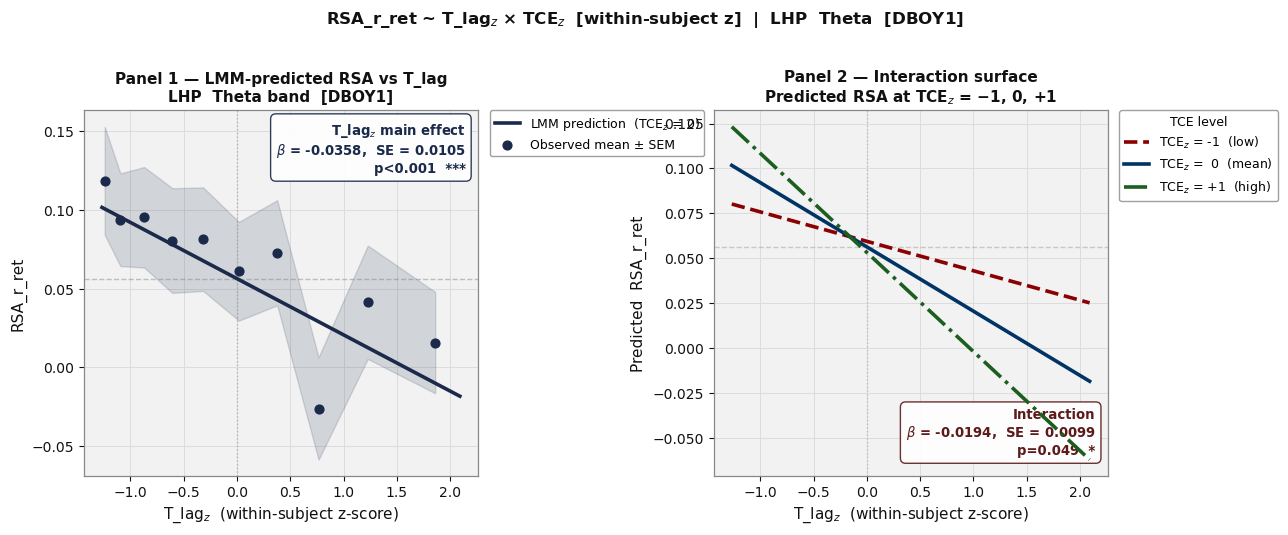


Figure saved: transition_lmm_tlag_tce_zscore/figure_p1p2.png


In [12]:
#!/usr/bin/env python3
"""
Figure: Panel 1 + Panel 2
==========================
Panel 1 — LMM-predicted RSA vs T_lag_z  (TCE_z = 0)
Panel 2 — Interaction: 3 lines at TCE_z = -1, 0, +1
White background, dark rich colors. Legends outside. No stats in title.
"""

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from statsmodels.regression.mixed_linear_model import MixedLM
warnings.filterwarnings('ignore')

# ── Config ─────────────────────────────────────────────────────────────────────
EXPERIMENT = 'DBOY1'
REGION     = 'LHP'
BAND       = 'theta'
OUTCOME    = 'RSA_r_ret'

RSA_CSV = Path(f'./rsa_lag_allregions/'
               f'ALL_SUBJECTS_{EXPERIMENT}_allregions_allbands_rsa_lag.csv')
TCE_CSV = Path('mean_temporal_clustering_per_list.csv')
OUT_DIR = Path('./transition_lmm_tlag_tce_zscore')
OUT_DIR.mkdir(exist_ok=True)

# ── Palette — white background, dark rich colors ───────────────────────────────
BG          = 'white'
AX_COLOR    = '#F2F2F2'
GRID_COLOR  = '#DCDCDC'
SPINE_COLOR = '#888888'
TEXT_COLOR  = '#111111'

# Panel 1 — observed + prediction
COLOR_OBS  = '#1B2A4A'   # very dark navy

# Panel 2 — 3 interaction lines, clearly distinct, all dark
LINE_PROPS = {
    'TCE$_z$ = -1  (low)':  dict(color='#8B0000', ls='--',  lw=2.6),  # dark red
    'TCE$_z$ =  0  (mean)': dict(color='#003366', ls='-',   lw=2.6),  # dark blue
    'TCE$_z$ = +1  (high)': dict(color='#1B5E20', ls='-.',  lw=2.6),  # dark green
}

# annotation box color for interaction stats
COLOR_INT = '#5C1A1A'

def style(ax):
    ax.set_facecolor(AX_COLOR)
    ax.grid(True, color=GRID_COLOR, lw=0.7, zorder=0)
    for sp in ax.spines.values():
        sp.set_edgecolor(SPINE_COLOR)
        sp.set_linewidth(0.9)
    ax.tick_params(colors=TEXT_COLOR, labelsize=10)
    ax.xaxis.label.set_color(TEXT_COLOR)
    ax.yaxis.label.set_color(TEXT_COLOR)
    ax.title.set_color(TEXT_COLOR)

def sig_stars(p):
    if not np.isfinite(p): return ''
    return ('***' if p < 0.001 else '**' if p < 0.01
            else '*' if p < 0.05 else 'n.s.')

def fmt_p(p):
    if not np.isfinite(p): return 'p=NaN'
    return 'p<0.001' if p < 0.001 else f'p={p:.3f}'

# =============================================================================
# Load & prepare
# =============================================================================
df = pd.read_csv(RSA_CSV)
df = df[(df['region'] == REGION) & (df['band'] == BAND)].copy()
df = df.rename(columns={'trial': 'list'})
df['subject'] = df['subject'].astype(str)

tce = pd.read_csv(TCE_CSV)
tce['subject'] = tce['subject'].astype(str)
tce = tce.rename(columns={'trial': 'list'})

df = df.merge(
    tce[['subject', 'session', 'list', 'mean_T_clustering']],
    on=['subject', 'session', 'list'], how='inner'
).dropna(subset=[OUTCOME, 'T_lag', 'mean_T_clustering'])

def zscore_within(x):
    s = x.std()
    return (x - x.mean()) / s if s > 0 else x * 0.0

df['T_lag_z'] = df.groupby('subject')['T_lag'].transform(zscore_within)
df['TCE_z']   = df.groupby('subject')['mean_T_clustering'].transform(zscore_within)
df['subj_sess']      = df['subject'] + '_' + df['session'].astype(str)
df['subj_sess_list'] = df['subj_sess'] + '_' + df['list'].astype(str)

print(f"N transitions: {len(df):,}  |  N subjects: {df['subject'].nunique()}")

# =============================================================================
# Fit LMM
# =============================================================================
lmm_result = None
for method in ['lbfgs', 'nm', 'powell']:
    try:
        model = MixedLM.from_formula(
            f'{OUTCOME} ~ T_lag_z * TCE_z',
            data       = df,
            groups     = df['subject'],
            vc_formula = {
                'subj_sess':      '0 + C(subj_sess)',
                'subj_sess_list': '0 + C(subj_sess_list)',
            },
        )
        lmm_result = model.fit(reml=True, method=method)
        if np.isfinite(lmm_result.llf):
            print(f"Converged ({method})  AIC={lmm_result.aic:.2f}")
            break
    except Exception as e:
        print(f"{method} failed: {e}")

if lmm_result is None or not np.isfinite(lmm_result.llf):
    raise RuntimeError("LMM failed to converge.")

b0     = lmm_result.params['Intercept']
b_t    = lmm_result.params['T_lag_z']
b_c    = lmm_result.params['TCE_z']
b_int  = lmm_result.params['T_lag_z:TCE_z']
se_t   = lmm_result.bse['T_lag_z']
se_int = lmm_result.bse['T_lag_z:TCE_z']
p_t    = lmm_result.pvalues['T_lag_z']
p_int  = lmm_result.pvalues['T_lag_z:TCE_z']

def predict(t, c):
    return b0 + b_t * t + b_c * c + b_int * t * c

t_grid = np.linspace(df['T_lag_z'].quantile(0.02),
                     df['T_lag_z'].quantile(0.98), 300)

print(f"\nT_lag_z:      beta={b_t:.4f}  SE={se_t:.4f}  {fmt_p(p_t)}  {sig_stars(p_t)}")
print(f"Interaction:  beta={b_int:.4f}  SE={se_int:.4f}  {fmt_p(p_int)}  {sig_stars(p_int)}")

# =============================================================================
# FIGURE
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
fig.patch.set_facecolor(BG)

# ── Panel 1 ───────────────────────────────────────────────────────────────────
ax = axes[0]
style(ax)

df['tlag_bin'] = pd.qcut(df['T_lag_z'], q=10, labels=False, duplicates='drop')
obs = (df.groupby('tlag_bin')[OUTCOME]
         .agg(['mean', 'sem',
               lambda x: df.loc[x.index, 'T_lag_z'].mean()])
         .reset_index())
obs.columns = ['bin', 'mean', 'sem', 'x_center']

ax.fill_between(obs['x_center'],
                obs['mean'] - obs['sem'],
                obs['mean'] + obs['sem'],
                color=COLOR_OBS, alpha=0.15, zorder=2)
ax.scatter(obs['x_center'], obs['mean'],
           color=COLOR_OBS, s=40, zorder=4,
           label='Observed mean ± SEM')
ax.plot(t_grid, predict(t_grid, 0.0),
        color=COLOR_OBS, lw=2.6, zorder=5,
        label='LMM prediction  (TCE$_z$ = 0)')

ax.axhline(b0, color=SPINE_COLOR, lw=1.0, ls='--', alpha=0.5)
ax.axvline(0,  color=SPINE_COLOR, lw=1.0, ls=':', alpha=0.5)

ax.text(0.97, 0.97,
        f"T_lag$_z$ main effect\n"
        f"$\\beta$ = {b_t:.4f},  SE = {se_t:.4f}\n"
        f"{fmt_p(p_t)}  {sig_stars(p_t)}",
        transform=ax.transAxes, ha='right', va='top', fontsize=9.5,
        color=COLOR_OBS, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.4', fc='white',
                  ec=COLOR_OBS, alpha=0.9))

ax.set_xlabel('T_lag$_z$  (within-subject z-score)', fontsize=11)
ax.set_ylabel(OUTCOME, fontsize=11)
ax.set_title(f'Panel 1 — LMM-predicted RSA vs T_lag\n'
             f'{REGION}  {BAND.capitalize()} band  [{EXPERIMENT}]',
             fontsize=11, fontweight='bold')

ax.legend(fontsize=9, facecolor='white', edgecolor=SPINE_COLOR,
          loc='upper left', bbox_to_anchor=(1.03, 1.0),
          borderaxespad=0)

# ── Panel 2 ───────────────────────────────────────────────────────────────────
ax = axes[1]
style(ax)

tce_levels = {
    'TCE$_z$ = -1  (low)':   -1.0,
    'TCE$_z$ =  0  (mean)':   0.0,
    'TCE$_z$ = +1  (high)':  +1.0,
}

for label, c_val in tce_levels.items():
    props = LINE_PROPS[label]
    ax.plot(t_grid, predict(t_grid, c_val),
            color=props['color'], ls=props['ls'], lw=props['lw'],
            label=label, zorder=4)

ax.axhline(b0, color=SPINE_COLOR, lw=1.0, ls='--', alpha=0.4)
ax.axvline(0,  color=SPINE_COLOR, lw=1.0, ls=':', alpha=0.4)

ax.text(0.97, 0.05,
        f"Interaction\n"
        f"$\\beta$ = {b_int:.4f},  SE = {se_int:.4f}\n"
        f"{fmt_p(p_int)}  {sig_stars(p_int)}",
        transform=ax.transAxes, ha='right', va='bottom', fontsize=9.5,
        color=COLOR_INT, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.4', fc='white',
                  ec=COLOR_INT, alpha=0.9))

ax.set_xlabel('T_lag$_z$  (within-subject z-score)', fontsize=11)
ax.set_ylabel(f'Predicted  {OUTCOME}', fontsize=11)
ax.set_title(f'Panel 2 — Interaction surface\n'
             f'Predicted RSA at TCE$_z$ = \u22121, 0, +1',
             fontsize=11, fontweight='bold')

ax.legend(fontsize=9, facecolor='white', edgecolor=SPINE_COLOR,
          loc='upper left', bbox_to_anchor=(1.03, 1.0),
          borderaxespad=0, title='TCE level', title_fontsize=9)

# ── Shared super-title (no stats) ─────────────────────────────────────────────
fig.suptitle(
    f'{OUTCOME} ~ T_lag$_z$ \u00d7 TCE$_z$  '
    f'[within-subject z]  |  {REGION}  {BAND.capitalize()}  [{EXPERIMENT}]',
    fontsize=12, fontweight='bold', y=1.02, color=TEXT_COLOR)

plt.tight_layout()
plt.subplots_adjust(wspace=0.6)
fig_path = OUT_DIR / 'figure_p1p2.png'
fig.savefig(fig_path, dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print(f"\nFigure saved: {fig_path}")

In [16]:
#!/usr/bin/env python3
"""
Figure: Panel 1 + Panel 2
==========================
Panel 1 — LMM-predicted RSA vs T_lag_z  (TCE_z = 0)
Panel 2 — Interaction: 3 lines at TCE_z = -1, 0, +1
White background, dark rich colors. Legends outside. No stats in title.
"""

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from statsmodels.regression.mixed_linear_model import MixedLM
warnings.filterwarnings('ignore')

# ── Config ─────────────────────────────────────────────────────────────────────
EXPERIMENT = 'DBOY1'
REGION     = 'RPH'
BAND       = 'theta'
OUTCOME    = 'RSA_r_ret'

RSA_CSV = Path(f'./rsa_lag_allregions/'
               f'ALL_SUBJECTS_{EXPERIMENT}_allregions_allbands_rsa_lag.csv')
TCE_CSV = Path('mean_temporal_clustering_per_list.csv')
OUT_DIR = Path('./transition_lmm_tlag_tce_zscore')
OUT_DIR.mkdir(exist_ok=True)

# ── Palette — white background, dark rich colors ───────────────────────────────
BG          = 'white'
AX_COLOR    = '#F2F2F2'
GRID_COLOR  = '#DCDCDC'
SPINE_COLOR = '#888888'
TEXT_COLOR  = '#111111'

# Panel 1 — observed + prediction
COLOR_OBS  = '#1B2A4A'   # very dark navy

# Panel 2 — 3 interaction lines, clearly distinct, all dark
LINE_PROPS = {
    'TCE$_z$ = -1  (low)':  dict(color='#8B0000', ls='--',  lw=2.6),  # dark red
    'TCE$_z$ =  0  (mean)': dict(color='#003366', ls='-',   lw=2.6),  # dark blue
    'TCE$_z$ = +1  (high)': dict(color='#1B5E20', ls='-.',  lw=2.6),  # dark green
}

# annotation box color for interaction stats
COLOR_INT = '#5C1A1A'

def style(ax):
    ax.set_facecolor(AX_COLOR)
    ax.grid(True, color=GRID_COLOR, lw=0.7, zorder=0)
    for sp in ax.spines.values():
        sp.set_edgecolor(SPINE_COLOR)
        sp.set_linewidth(0.9)
    ax.tick_params(colors=TEXT_COLOR, labelsize=10)
    ax.xaxis.label.set_color(TEXT_COLOR)
    ax.yaxis.label.set_color(TEXT_COLOR)
    ax.title.set_color(TEXT_COLOR)

def sig_stars(p):
    if not np.isfinite(p): return ''
    return ('***' if p < 0.001 else '**' if p < 0.01
            else '*' if p < 0.05 else 'n.s.')

def fmt_p(p):
    if not np.isfinite(p): return 'p=NaN'
    return 'p<0.001' if p < 0.001 else f'p={p:.3f}'

# =============================================================================
# Load & prepare
# =============================================================================
df = pd.read_csv(RSA_CSV)
df = df[(df['region'] == REGION) & (df['band'] == BAND)].copy()
df = df.rename(columns={'trial': 'list'})
df['subject'] = df['subject'].astype(str)

tce = pd.read_csv(TCE_CSV)
tce['subject'] = tce['subject'].astype(str)
tce = tce.rename(columns={'trial': 'list'})

df = df.merge(
    tce[['subject', 'session', 'list', 'mean_T_clustering']],
    on=['subject', 'session', 'list'], how='inner'
).dropna(subset=[OUTCOME, 'T_lag', 'mean_T_clustering'])

def zscore_within(x):
    s = x.std()
    return (x - x.mean()) / s if s > 0 else x * 0.0

df['T_lag_z'] = df.groupby('subject')['T_lag'].transform(zscore_within)
df['TCE_z']   = df.groupby('subject')['mean_T_clustering'].transform(zscore_within)
df['subj_sess']      = df['subject'] + '_' + df['session'].astype(str)
df['subj_sess_list'] = df['subj_sess'] + '_' + df['list'].astype(str)

print(f"N transitions: {len(df):,}  |  N subjects: {df['subject'].nunique()}")

# =============================================================================
# Fit LMM
# =============================================================================
lmm_result = None
for method in ['lbfgs', 'nm', 'powell']:
    try:
        model = MixedLM.from_formula(
            f'{OUTCOME} ~ T_lag_z * TCE_z',
            data       = df,
            groups     = df['subject'],
            vc_formula = {
                'subj_sess':      '0 + C(subj_sess)',
                'subj_sess_list': '0 + C(subj_sess_list)',
            },
        )
        lmm_result = model.fit(reml=True, method=method)
        if np.isfinite(lmm_result.llf):
            print(f"Converged ({method})  AIC={lmm_result.aic:.2f}")
            break
    except Exception as e:
        print(f"{method} failed: {e}")

if lmm_result is None or not np.isfinite(lmm_result.llf):
    raise RuntimeError("LMM failed to converge.")

b0     = lmm_result.params['Intercept']
b_t    = lmm_result.params['T_lag_z']
b_c    = lmm_result.params['TCE_z']
b_int  = lmm_result.params['T_lag_z:TCE_z']
se_t   = lmm_result.bse['T_lag_z']
se_int = lmm_result.bse['T_lag_z:TCE_z']
p_t    = lmm_result.pvalues['T_lag_z']
p_int  = lmm_result.pvalues['T_lag_z:TCE_z']

def predict(t, c):
    return b0 + b_t * t + b_c * c + b_int * t * c

t_grid = np.linspace(df['T_lag_z'].quantile(0.02),
                     df['T_lag_z'].quantile(0.98), 300)

print(f"\nT_lag_z:      beta={b_t:.4f}  SE={se_t:.4f}  {fmt_p(p_t)}  {sig_stars(p_t)}")
print(f"Interaction:  beta={b_int:.4f}  SE={se_int:.4f}  {fmt_p(p_int)}  {sig_stars(p_int)}")

# =============================================================================
# FIGURE
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
fig.patch.set_facecolor(BG)

# ── Panel 1 ───────────────────────────────────────────────────────────────────
ax = axes[0]
style(ax)

df['tlag_bin'] = pd.qcut(df['T_lag_z'], q=10, labels=False, duplicates='drop')
obs = (df.groupby('tlag_bin')[OUTCOME]
         .agg(['mean', 'sem',
               lambda x: df.loc[x.index, 'T_lag_z'].mean()])
         .reset_index())
obs.columns = ['bin', 'mean', 'sem', 'x_center']

ax.fill_between(obs['x_center'],
                obs['mean'] - obs['sem'],
                obs['mean'] + obs['sem'],
                color=COLOR_OBS, alpha=0.15, zorder=2)
ax.scatter(obs['x_center'], obs['mean'],
           color=COLOR_OBS, s=40, zorder=4,
           label='Observed mean ± SEM')
ax.plot(t_grid, predict(t_grid, 0.0),
        color=COLOR_OBS, lw=2.6, zorder=5,
        label='LMM prediction  (TCE$_z$ = 0)')

ax.axhline(b0, color=SPINE_COLOR, lw=1.0, ls='--', alpha=0.5)
ax.axvline(0,  color=SPINE_COLOR, lw=1.0, ls=':', alpha=0.5)

ax.text(0.97, 0.97,
        f"T_lag$_z$ main effect\n"
        f"$\\beta$ = {b_t:.4f},  SE = {se_t:.4f}\n"
        f"{fmt_p(p_t)}  {sig_stars(p_t)}",
        transform=ax.transAxes, ha='right', va='top', fontsize=9.5,
        color=COLOR_OBS, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.4', fc='white',
                  ec=COLOR_OBS, alpha=0.9))

ax.set_xlabel('T_lag$_z$  (within-subject z-score)', fontsize=11)
ax.set_ylabel(OUTCOME, fontsize=11)
ax.set_title(f'Panel 1 — LMM-predicted RSA vs T_lag\n'
             f'{REGION}  {BAND.capitalize()} band  [{EXPERIMENT}]',
             fontsize=11, fontweight='bold')

ax.legend(fontsize=9, facecolor='white', edgecolor=SPINE_COLOR,
          loc='upper left', bbox_to_anchor=(1.03, 1.0),
          borderaxespad=0)

# ── Panel 2 ───────────────────────────────────────────────────────────────────
ax = axes[1]
style(ax)

tce_levels = {
    'TCE$_z$ = -1  (low)':   -1.0,
    'TCE$_z$ =  0  (mean)':   0.0,
    'TCE$_z$ = +1  (high)':  +1.0,
}

for label, c_val in tce_levels.items():
    props = LINE_PROPS[label]
    ax.plot(t_grid, predict(t_grid, c_val),
            color=props['color'], ls=props['ls'], lw=props['lw'],
            label=label, zorder=4)

ax.axhline(b0, color=SPINE_COLOR, lw=1.0, ls='--', alpha=0.4)
ax.axvline(0,  color=SPINE_COLOR, lw=1.0, ls=':', alpha=0.4)

ax.text(0.97, 0.05,
        f"Interaction\n"
        f"$\\beta$ = {b_int:.4f},  SE = {se_int:.4f}\n"
        f"{fmt_p(p_int)}  {sig_stars(p_int)}",
        transform=ax.transAxes, ha='right', va='bottom', fontsize=9.5,
        color=COLOR_INT, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.4', fc='white',
                  ec=COLOR_INT, alpha=0.9))

ax.set_xlabel('T_lag$_z$  (within-subject z-score)', fontsize=11)
ax.set_ylabel(f'Predicted  {OUTCOME}', fontsize=11)
ax.set_title(f'Panel 2 — Interaction surface\n'
             f'Predicted RSA at TCE$_z$ = \u22121, 0, +1',
             fontsize=11, fontweight='bold')

ax.legend(fontsize=9, facecolor='white', edgecolor=SPINE_COLOR,
          loc='upper left', bbox_to_anchor=(1.03, 1.0),
          borderaxespad=0, title='TCE level', title_fontsize=9)

# ── Shared super-title (no stats) ─────────────────────────────────────────────
fig.suptitle(
    f'{OUTCOME} ~ T_lag$_z$ \u00d7 TCE$_z$  '
    f'[within-subject z]  |  {REGION}  {BAND.capitalize()}  [{EXPERIMENT}]',
    fontsize=12, fontweight='bold', y=1.02, color=TEXT_COLOR)

plt.tight_layout()
plt.subplots_adjust(wspace=0.6)
fig_path = OUT_DIR / 'figure_p1p2.png'
fig.savefig(fig_path, dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print(f"\nFigure saved: {fig_path}")

N transitions: 0  |  N subjects: 0
lbfgs failed: zero-size array to reduction operation maximum which has no identity
nm failed: zero-size array to reduction operation maximum which has no identity
powell failed: zero-size array to reduction operation maximum which has no identity


RuntimeError: LMM failed to converge.

N transitions : 1,814  |  N subjects: 27
List range    : 0 – 6  (mean=1.5)
Saved: transition_data_theta_lhp_listnum.csv

Fitting LMM ...
  Formula: RSA_r_ret ~ T_lag_z * list_z
  N transitions : 1,814
  N subjects    : 27
  N sessions    : 58
  N lists       : 171
  Converged (lbfgs)  AIC=nan

LMM: RSA_r_ret ~ T_lag_z * list_z
Term                                            beta        SE        z          p   sig
-----------------------------------------------------------------
Intercept                                     0.0597    0.0154    3.877     0.0001   ***
T_lag_z  (main effect)                       -0.0337    0.0104   -3.238     0.0012    **
list_z  (main effect)                        -0.0005    0.0132   -0.040     0.9679  n.s.
T_lag_z x list_z  (interaction)              -0.0080    0.0108   -0.747     0.4549  n.s.
-----------------------------------------------------------------
AIC=nan  N=1,814


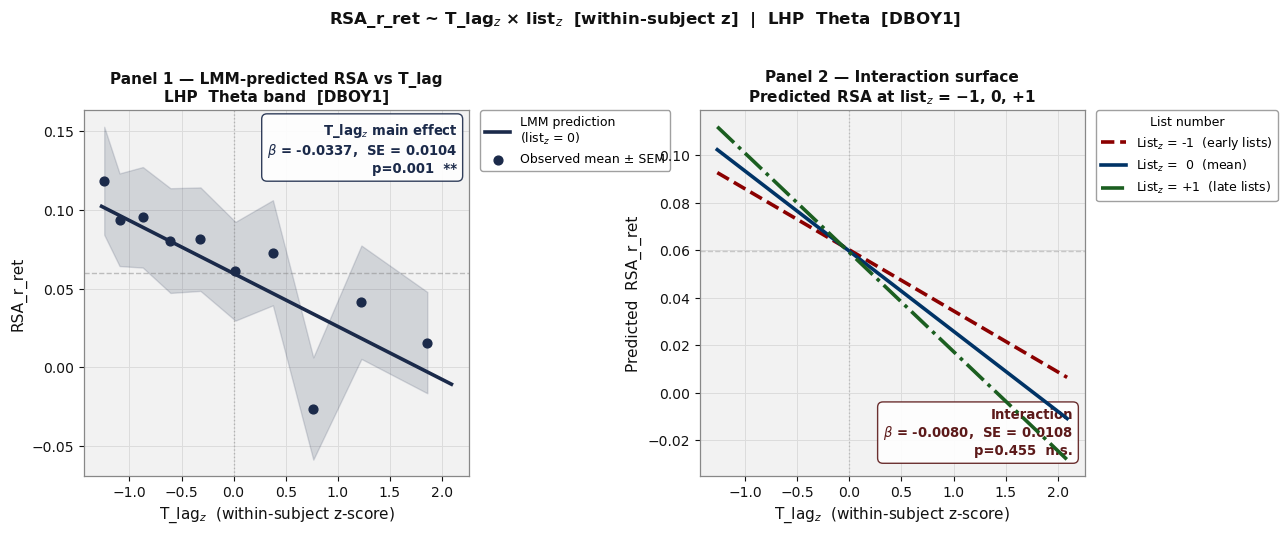


Figure saved: transition_lmm_tlag_listnum/figure_tlag_listnum.png

DONE



In [19]:
#!/usr/bin/env python3
"""
Single-stage transition-level LMM
===================================
RSA_r_ret ~ T_lag_z * list_z + (1 | subject / session / list)

Moderator = list number (trial number within session),
            z-scored within subject x session

Question: does the T_lag -> RSA effect change across lists?
          i.e. does neural temporal organisation strengthen or
          weaken as the session progresses?

Panel 1 — LMM-predicted RSA vs T_lag_z  (list_z = 0)
Panel 2 — Interaction: 3 lines at list_z = -1, 0, +1
"""

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from statsmodels.regression.mixed_linear_model import MixedLM
warnings.filterwarnings('ignore')

# ── Config ─────────────────────────────────────────────────────────────────────
EXPERIMENT = 'DBOY1'
REGION     = 'LHP'
BAND       = 'theta'
OUTCOME    = 'RSA_r_ret'

RSA_CSV = Path(f'./rsa_lag_allregions/'
               f'ALL_SUBJECTS_{EXPERIMENT}_allregions_allbands_rsa_lag.csv')
OUT_DIR = Path('./transition_lmm_tlag_listnum')
OUT_DIR.mkdir(exist_ok=True)

# ── Palette ────────────────────────────────────────────────────────────────────
BG          = 'white'
AX_COLOR    = '#F2F2F2'
GRID_COLOR  = '#DCDCDC'
SPINE_COLOR = '#888888'
TEXT_COLOR  = '#111111'
COLOR_OBS   = '#1B2A4A'
COLOR_INT   = '#5C1A1A'

LINE_PROPS = {
    'List$_z$ = -1  (early lists)':  dict(color='#8B0000', ls='--',  lw=2.6),
    'List$_z$ =  0  (mean)':          dict(color='#003366', ls='-',   lw=2.6),
    'List$_z$ = +1  (late lists)':    dict(color='#1B5E20', ls='-.',  lw=2.6),
}

def style(ax):
    ax.set_facecolor(AX_COLOR)
    ax.grid(True, color=GRID_COLOR, lw=0.7, zorder=0)
    for sp in ax.spines.values():
        sp.set_edgecolor(SPINE_COLOR)
        sp.set_linewidth(0.9)
    ax.tick_params(colors=TEXT_COLOR, labelsize=10)
    ax.xaxis.label.set_color(TEXT_COLOR)
    ax.yaxis.label.set_color(TEXT_COLOR)
    ax.title.set_color(TEXT_COLOR)

def sig_stars(p):
    if not np.isfinite(p): return ''
    return ('***' if p < 0.001 else '**' if p < 0.01
            else '*' if p < 0.05 else 'n.s.')

def fmt_p(p):
    if not np.isfinite(p): return 'p=NaN'
    return 'p<0.001' if p < 0.001 else f'p={p:.3f}'

# =============================================================================
# Load & prepare
# =============================================================================
df = pd.read_csv(RSA_CSV)
df = df[(df['region'] == REGION) & (df['band'] == BAND)].copy()
df = df.rename(columns={'trial': 'list'})
df['subject'] = df['subject'].astype(str)
df = df.dropna(subset=[OUTCOME, 'T_lag', 'list'])

print(f"N transitions : {len(df):,}  |  N subjects: {df['subject'].nunique()}")
print(f"List range    : {df['list'].min():.0f} – {df['list'].max():.0f}  "
      f"(mean={df['list'].mean():.1f})")

# =============================================================================
# Within-subject z-score
# z-score list number within subject (across all sessions)
# so list_z reflects where in the subject's overall experiment this list fell
# =============================================================================
def zscore_within(x):
    s = x.std()
    return (x - x.mean()) / s if s > 0 else x * 0.0

df['T_lag_z'] = df.groupby('subject')['T_lag'].transform(zscore_within)
df['list_z']  = df.groupby('subject')['list'].transform(zscore_within)

df['subj_sess']      = df['subject'] + '_' + df['session'].astype(str)
df['subj_sess_list'] = df['subj_sess'] + '_' + df['list'].astype(str)

out_csv = OUT_DIR / f'transition_data_{BAND}_{REGION.lower()}_listnum.csv'
df.to_csv(out_csv, index=False)
print(f"Saved: {out_csv.name}")

# =============================================================================
# Fit LMM
# =============================================================================
print(f"\nFitting LMM ...")
print(f"  Formula: {OUTCOME} ~ T_lag_z * list_z")
print(f"  N transitions : {len(df):,}")
print(f"  N subjects    : {df['subject'].nunique()}")
print(f"  N sessions    : {df['subj_sess'].nunique()}")
print(f"  N lists       : {df['subj_sess_list'].nunique()}")

lmm_result = None
for method in ['lbfgs', 'nm', 'powell']:
    try:
        model = MixedLM.from_formula(
            f'{OUTCOME} ~ T_lag_z * list_z',
            data       = df,
            groups     = df['subject'],
            vc_formula = {
                'subj_sess':      '0 + C(subj_sess)',
                'subj_sess_list': '0 + C(subj_sess_list)',
            },
        )
        lmm_result = model.fit(reml=True, method=method)
        if np.isfinite(lmm_result.llf):
            print(f"  Converged ({method})  AIC={lmm_result.aic:.2f}")
            break
    except Exception as e:
        print(f"  {method} failed: {e}")
        lmm_result = None

if lmm_result is None or not np.isfinite(lmm_result.llf):
    raise RuntimeError("LMM failed to converge.")

# =============================================================================
# Extract results
# =============================================================================
terms = {
    'Intercept':          'Intercept',
    'T_lag_z':            'T_lag_z  (main effect)',
    'list_z':             'list_z  (main effect)',
    'T_lag_z:list_z':     'T_lag_z x list_z  (interaction)',
}

print(f"\n{'='*65}")
print(f"LMM: {OUTCOME} ~ T_lag_z * list_z")
print(f"{'='*65}")
print(f"{'Term':<42} {'beta':>9} {'SE':>9} {'z':>8} {'p':>10} {'sig':>5}")
print(f"{'-'*65}")

results = {}
for col, label in terms.items():
    if col in lmm_result.params.index:
        b  = lmm_result.params[col]
        s  = lmm_result.bse[col]
        z  = lmm_result.tvalues[col]
        pv = lmm_result.pvalues[col]
        results[col] = dict(beta=b, se=s, z=z, p=pv)
        print(f"{label:<42} {b:>9.4f} {s:>9.4f} {z:>8.3f} "
              f"{pv:>10.4f} {sig_stars(pv):>5}")

print(f"{'-'*65}")
print(f"AIC={lmm_result.aic:.2f}  N={int(lmm_result.nobs):,}")
print(f"{'='*65}")

with open(OUT_DIR / 'LMM_summary_listnum.txt', 'w') as f:
    f.write(f"Model: {OUTCOME} ~ T_lag_z * list_z\n")
    f.write(f"Region: {REGION}  Band: {BAND}  Experiment: {EXPERIMENT}\n\n")
    f.write(str(lmm_result.summary()))

b0     = results['Intercept']['beta']
b_t    = results['T_lag_z']['beta']
b_l    = results['list_z']['beta']
b_int  = results['T_lag_z:list_z']['beta']
se_t   = results['T_lag_z']['se']
se_int = results['T_lag_z:list_z']['se']
p_t    = results['T_lag_z']['p']
p_int  = results['T_lag_z:list_z']['p']

def predict(t, l):
    return b0 + b_t * t + b_l * l + b_int * t * l

t_grid = np.linspace(df['T_lag_z'].quantile(0.02),
                     df['T_lag_z'].quantile(0.98), 300)

# =============================================================================
# FIGURE
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
fig.patch.set_facecolor(BG)

# ── Panel 1: observed + LMM prediction at list_z = 0 ─────────────────────────
ax = axes[0]
style(ax)

df['tlag_bin'] = pd.qcut(df['T_lag_z'], q=10, labels=False, duplicates='drop')
obs = (df.groupby('tlag_bin')[OUTCOME]
         .agg(['mean', 'sem',
               lambda x: df.loc[x.index, 'T_lag_z'].mean()])
         .reset_index())
obs.columns = ['bin', 'mean', 'sem', 'x_center']

ax.fill_between(obs['x_center'],
                obs['mean'] - obs['sem'],
                obs['mean'] + obs['sem'],
                color=COLOR_OBS, alpha=0.15, zorder=2)
ax.scatter(obs['x_center'], obs['mean'],
           color=COLOR_OBS, s=40, zorder=4,
           label='Observed mean ± SEM')
ax.plot(t_grid, predict(t_grid, 0.0),
        color=COLOR_OBS, lw=2.6, zorder=5,
        label='LMM prediction\n(list$_z$ = 0)')

ax.axhline(b0, color=SPINE_COLOR, lw=1.0, ls='--', alpha=0.5)
ax.axvline(0,  color=SPINE_COLOR, lw=1.0, ls=':', alpha=0.5)

ax.text(0.97, 0.97,
        f"T_lag$_z$ main effect\n"
        f"$\\beta$ = {b_t:.4f},  SE = {se_t:.4f}\n"
        f"{fmt_p(p_t)}  {sig_stars(p_t)}",
        transform=ax.transAxes, ha='right', va='top', fontsize=9.5,
        color=COLOR_OBS, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.4', fc='white',
                  ec=COLOR_OBS, alpha=0.9))

ax.set_xlabel('T_lag$_z$  (within-subject z-score)', fontsize=11)
ax.set_ylabel(OUTCOME, fontsize=11)
ax.set_title(f'Panel 1 — LMM-predicted RSA vs T_lag\n'
             f'{REGION}  {BAND.capitalize()} band  [{EXPERIMENT}]',
             fontsize=11, fontweight='bold')

ax.legend(fontsize=9, facecolor='white', edgecolor=SPINE_COLOR,
          loc='upper left', bbox_to_anchor=(1.03, 1.0),
          borderaxespad=0)

# ── Panel 2: interaction — 3 lines at list_z = -1, 0, +1 ─────────────────────
ax = axes[1]
style(ax)

list_levels = {
    'List$_z$ = -1  (early lists)':  -1.0,
    'List$_z$ =  0  (mean)':          0.0,
    'List$_z$ = +1  (late lists)':   +1.0,
}

for label, l_val in list_levels.items():
    props = LINE_PROPS[label]
    ax.plot(t_grid, predict(t_grid, l_val),
            color=props['color'], ls=props['ls'], lw=props['lw'],
            label=label, zorder=4)

ax.axhline(b0, color=SPINE_COLOR, lw=1.0, ls='--', alpha=0.4)
ax.axvline(0,  color=SPINE_COLOR, lw=1.0, ls=':', alpha=0.4)

ax.text(0.97, 0.05,
        f"Interaction\n"
        f"$\\beta$ = {b_int:.4f},  SE = {se_int:.4f}\n"
        f"{fmt_p(p_int)}  {sig_stars(p_int)}",
        transform=ax.transAxes, ha='right', va='bottom', fontsize=9.5,
        color=COLOR_INT, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.4', fc='white',
                  ec=COLOR_INT, alpha=0.9))

ax.set_xlabel('T_lag$_z$  (within-subject z-score)', fontsize=11)
ax.set_ylabel(f'Predicted  {OUTCOME}', fontsize=11)
ax.set_title(f'Panel 2 — Interaction surface\n'
             f'Predicted RSA at list$_z$ = \u22121, 0, +1',
             fontsize=11, fontweight='bold')

ax.legend(fontsize=9, facecolor='white', edgecolor=SPINE_COLOR,
          loc='upper left', bbox_to_anchor=(1.03, 1.0),
          borderaxespad=0, title='List number', title_fontsize=9)

# ── Super-title ────────────────────────────────────────────────────────────────
fig.suptitle(
    f'{OUTCOME} ~ T_lag$_z$ \u00d7 list$_z$  '
    f'[within-subject z]  |  {REGION}  {BAND.capitalize()}  [{EXPERIMENT}]',
    fontsize=12, fontweight='bold', y=1.02, color=TEXT_COLOR)

plt.tight_layout()
plt.subplots_adjust(wspace=0.6)
fig_path = OUT_DIR / 'figure_tlag_listnum.png'
fig.savefig(fig_path, dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print(f"\nFigure saved: {fig_path}")
print(f"\n{'='*65}")
print("DONE")
print(f"{'='*65}\n")


LMM: mean_RSA ~ SP_lag_z * SCE_z  |  RLTC  beta  [DBOY1]

Transitions loaded: 2,089  (29 subjects)

Averaged  RSA_r_enc  +  RSA_r_enc  ->  'mean_RSA'
mean_RSA: mean=0.0238  SD=0.2007  NaN=0

Using SCE column: 'mean_SP_clustering'
After SCE merge + dropna: 2,089 transitions  (29 subjects)
Saved: transition_data_beta_rltc_splag_sce.csv

Fitting LMM ...
  Formula: mean_RSA ~ SP_lag_z * SCE_z
  N transitions : 2,089
  N subjects    : 29
  N sessions    : 61
  N lists       : 179
  Converged (lbfgs)  AIC=nan

LMM: mean_RSA ~ SP_lag_z * SCE_z
Term                                            beta        SE        z          p   sig
-----------------------------------------------------------------
Intercept                                     0.0282    0.0071    3.946     0.0001   ***
SP_lag_z  (main effect)                      -0.0096    0.0045   -2.147     0.0318     *
SCE_z  (main effect)                          0.0002    0.0061    0.032     0.9742  n.s.
SP_lag_z x SCE_z  (interaction)   

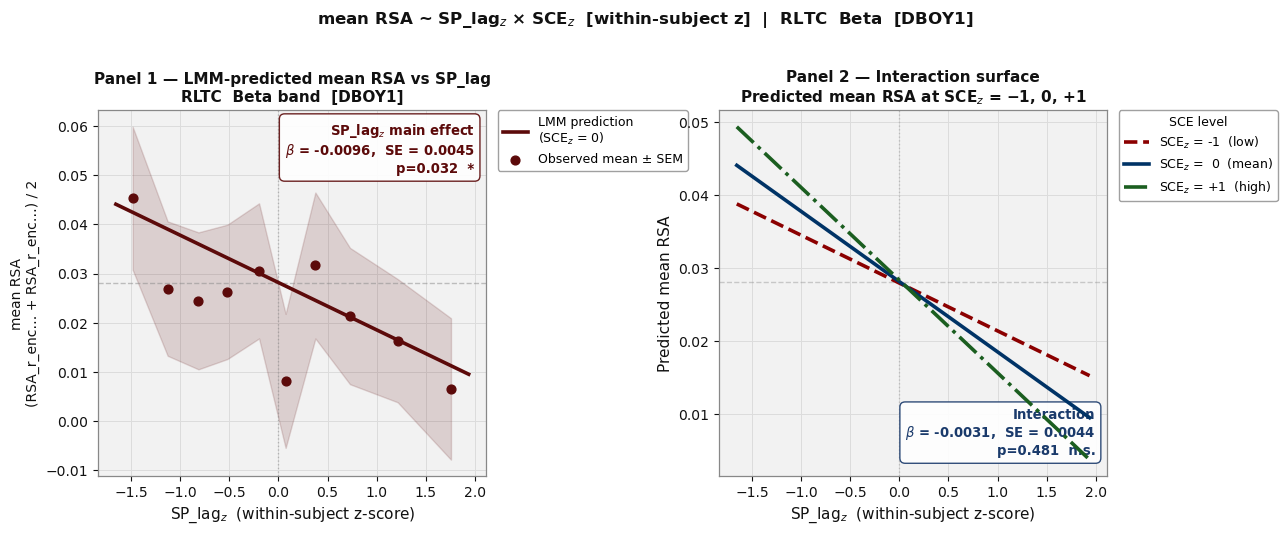


Figure saved: transition_lmm_splag_sce_rhp/figure_splag_sce_rhp.png

DONE



In [26]:
#!/usr/bin/env python3
"""
Single-stage transition-level LMM  —  RHP  theta
==================================================
DV      : mean_RSA = average of RSA_r_enc_i_ret_j and RSA_r_enc_j_ret_i
           (symmetric cross-RSA between word i and word j)
Predictor: SP_lag_z  (spatial lag, within-subject z-score)
Moderator: SCE_list  (mean spatial clustering score per list,
                      from mean_spatial_clustering_per_list.csv,
                      within-subject z-scored)

Model:
  mean_RSA ~ SP_lag_z * SCE_z + (1|subject) + (1|subject:session)
                                             + (1|subject:session:list)

Panel 1 — LMM-predicted mean_RSA vs SP_lag_z  (SCE_z = 0)
Panel 2 — Interaction: 3 lines at SCE_z = -1, 0, +1
"""

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from statsmodels.regression.mixed_linear_model import MixedLM
warnings.filterwarnings('ignore')

# ── Config ─────────────────────────────────────────────────────────────────────
EXPERIMENT = 'DBOY1'
REGION     = 'RLTC'
BAND       = 'beta'

# The two cross-RSA columns to average
RSA_COL_A  = 'RSA_r_enc'
RSA_COL_B  = 'RSA_r_enc'
OUTCOME    = 'mean_RSA'            # computed below

RSA_CSV = Path(f'./rsa_lag_allregions/'
               f'ALL_SUBJECTS_{EXPERIMENT}_allregions_allbands_rsa_lag.csv')
SCE_CSV = Path('mean_spatial_clustering_per_list.csv')
OUT_DIR = Path('./transition_lmm_splag_sce_rhp')
OUT_DIR.mkdir(exist_ok=True)

# ── Palette ────────────────────────────────────────────────────────────────────
BG          = 'white'
AX_COLOR    = '#F2F2F2'
GRID_COLOR  = '#DCDCDC'
SPINE_COLOR = '#888888'
TEXT_COLOR  = '#111111'
COLOR_OBS   = '#5C0A0A'   # dark red (RHP colour)
COLOR_INT   = '#1A3A6B'   # dark navy for annotation

LINE_PROPS = {
    'SCE$_z$ = -1  (low)':  dict(color='#8B0000', ls='--',  lw=2.6),
    'SCE$_z$ =  0  (mean)': dict(color='#003366', ls='-',   lw=2.6),
    'SCE$_z$ = +1  (high)': dict(color='#1B5E20', ls='-.',  lw=2.6),
}

def style(ax):
    ax.set_facecolor(AX_COLOR)
    ax.grid(True, color=GRID_COLOR, lw=0.7, zorder=0)
    for sp in ax.spines.values():
        sp.set_edgecolor(SPINE_COLOR)
        sp.set_linewidth(0.9)
    ax.tick_params(colors=TEXT_COLOR, labelsize=10)
    ax.xaxis.label.set_color(TEXT_COLOR)
    ax.yaxis.label.set_color(TEXT_COLOR)
    ax.title.set_color(TEXT_COLOR)

def sig_stars(p):
    if not np.isfinite(p): return ''
    return ('***' if p < 0.001 else '**' if p < 0.01
            else '*' if p < 0.05 else 'n.s.')

def fmt_p(p):
    if not np.isfinite(p): return 'p=NaN'
    return 'p<0.001' if p < 0.001 else f'p={p:.3f}'

# =============================================================================
# STEP 1 — Load RSA data, filter to RHP theta
# =============================================================================
print(f"\n{'='*65}")
print(f"LMM: mean_RSA ~ SP_lag_z * SCE_z  |  {REGION}  {BAND}  [{EXPERIMENT}]")
print(f"{'='*65}")

df = pd.read_csv(RSA_CSV)
df = df[(df['region'] == REGION) & (df['band'] == BAND)].copy()
df = df.rename(columns={'trial': 'list'})
df['subject'] = df['subject'].astype(str)

print(f"\nTransitions loaded: {len(df):,}  ({df['subject'].nunique()} subjects)")

# =============================================================================
# STEP 2 — Average the two cross-RSA columns
# =============================================================================
missing = [c for c in [RSA_COL_A, RSA_COL_B] if c not in df.columns]
if missing:
    raise KeyError(f"Missing RSA columns: {missing}\n"
                   f"Available: {df.columns.tolist()}")

df[OUTCOME] = df[[RSA_COL_A, RSA_COL_B]].mean(axis=1)

print(f"\nAveraged  {RSA_COL_A}  +  {RSA_COL_B}  ->  '{OUTCOME}'")
print(f"mean_RSA: mean={df[OUTCOME].mean():.4f}  "
      f"SD={df[OUTCOME].std():.4f}  "
      f"NaN={(df[OUTCOME].isna().sum())}")

# =============================================================================
# STEP 3 — Merge list-level spatial clustering score
# =============================================================================
sce = pd.read_csv(SCE_CSV)
sce['subject'] = sce['subject'].astype(str)

# handle possible column name variants
if 'trial' in sce.columns:
    sce = sce.rename(columns={'trial': 'list'})

# find the clustering column (flexible naming)
sce_candidates = [c for c in sce.columns
                  if 'spatial' in c.lower() or 'sp_clust' in c.lower()
                  or 'mean_sp' in c.lower() or 'sce' in c.lower()]
if not sce_candidates:
    print(f"SCE CSV columns: {sce.columns.tolist()}")
    raise KeyError("Cannot find spatial clustering column — check CSV above.")

SCE_COL = sce_candidates[0]
print(f"\nUsing SCE column: '{SCE_COL}'")

df = df.merge(
    sce[['subject', 'session', 'list', SCE_COL]],
    on=['subject', 'session', 'list'], how='inner'
).dropna(subset=[OUTCOME, 'SP_lag', SCE_COL])

print(f"After SCE merge + dropna: {len(df):,} transitions  "
      f"({df['subject'].nunique()} subjects)")

# =============================================================================
# STEP 4 — Within-subject z-score
# =============================================================================
def zscore_within(x):
    s = x.std()
    return (x - x.mean()) / s if s > 0 else x * 0.0

df['SP_lag_z'] = df.groupby('subject')['SP_lag'].transform(zscore_within)
df['SCE_z']    = df.groupby('subject')[SCE_COL].transform(zscore_within)

df['subj_sess']      = df['subject'] + '_' + df['session'].astype(str)
df['subj_sess_list'] = df['subj_sess'] + '_' + df['list'].astype(str)

out_csv = OUT_DIR / f'transition_data_{BAND}_{REGION.lower()}_splag_sce.csv'
df.to_csv(out_csv, index=False)
print(f"Saved: {out_csv.name}")

# =============================================================================
# STEP 5 — Fit LMM
# =============================================================================
print(f"\nFitting LMM ...")
print(f"  Formula: {OUTCOME} ~ SP_lag_z * SCE_z")
print(f"  N transitions : {len(df):,}")
print(f"  N subjects    : {df['subject'].nunique()}")
print(f"  N sessions    : {df['subj_sess'].nunique()}")
print(f"  N lists       : {df['subj_sess_list'].nunique()}")

lmm_result = None
for method in ['lbfgs', 'nm', 'powell']:
    try:
        model = MixedLM.from_formula(
            f'{OUTCOME} ~ SP_lag_z * SCE_z',
            data       = df,
            groups     = df['subject'],
            vc_formula = {
                'subj_sess':      '0 + C(subj_sess)',
                'subj_sess_list': '0 + C(subj_sess_list)',
            },
        )
        lmm_result = model.fit(reml=True, method=method)
        if np.isfinite(lmm_result.llf):
            print(f"  Converged ({method})  AIC={lmm_result.aic:.2f}")
            break
    except Exception as e:
        print(f"  {method} failed: {e}")
        lmm_result = None

if lmm_result is None or not np.isfinite(lmm_result.llf):
    raise RuntimeError("LMM failed to converge.")

# =============================================================================
# STEP 6 — Extract results
# =============================================================================
terms = {
    'Intercept':        'Intercept',
    'SP_lag_z':         'SP_lag_z  (main effect)',
    'SCE_z':            'SCE_z  (main effect)',
    'SP_lag_z:SCE_z':   'SP_lag_z x SCE_z  (interaction)',
}

print(f"\n{'='*65}")
print(f"LMM: {OUTCOME} ~ SP_lag_z * SCE_z")
print(f"{'='*65}")
print(f"{'Term':<42} {'beta':>9} {'SE':>9} {'z':>8} {'p':>10} {'sig':>5}")
print(f"{'-'*65}")

results = {}
for col, label in terms.items():
    if col in lmm_result.params.index:
        b  = lmm_result.params[col]
        s  = lmm_result.bse[col]
        z  = lmm_result.tvalues[col]
        pv = lmm_result.pvalues[col]
        results[col] = dict(beta=b, se=s, z=z, p=pv)
        print(f"{label:<42} {b:>9.4f} {s:>9.4f} {z:>8.3f} "
              f"{pv:>10.4f} {sig_stars(pv):>5}")

print(f"{'-'*65}")
print(f"AIC={lmm_result.aic:.2f}  N={int(lmm_result.nobs):,}")
print(f"{'='*65}")

with open(OUT_DIR / 'LMM_summary_splag_sce.txt', 'w') as f:
    f.write(f"Model: {OUTCOME} ~ SP_lag_z * SCE_z\n")
    f.write(f"DV: mean({RSA_COL_A}, {RSA_COL_B})\n")
    f.write(f"Region: {REGION}  Band: {BAND}  Experiment: {EXPERIMENT}\n\n")
    f.write(str(lmm_result.summary()))

b0     = results['Intercept']['beta']
b_sp   = results['SP_lag_z']['beta']
b_sce  = results['SCE_z']['beta']
b_int  = results['SP_lag_z:SCE_z']['beta']
se_sp  = results['SP_lag_z']['se']
se_int = results['SP_lag_z:SCE_z']['se']
p_sp   = results['SP_lag_z']['p']
p_int  = results['SP_lag_z:SCE_z']['p']

def predict(sp, sce):
    return b0 + b_sp * sp + b_sce * sce + b_int * sp * sce

sp_grid = np.linspace(df['SP_lag_z'].quantile(0.02),
                      df['SP_lag_z'].quantile(0.98), 300)

# =============================================================================
# FIGURE
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
fig.patch.set_facecolor(BG)

# ── Panel 1: observed + LMM prediction at SCE_z = 0 ──────────────────────────
ax = axes[0]
style(ax)

df['splag_bin'] = pd.qcut(df['SP_lag_z'], q=10, labels=False, duplicates='drop')
obs = (df.groupby('splag_bin')[OUTCOME]
         .agg(['mean', 'sem',
               lambda x: df.loc[x.index, 'SP_lag_z'].mean()])
         .reset_index())
obs.columns = ['bin', 'mean', 'sem', 'x_center']

ax.fill_between(obs['x_center'],
                obs['mean'] - obs['sem'],
                obs['mean'] + obs['sem'],
                color=COLOR_OBS, alpha=0.15, zorder=2)
ax.scatter(obs['x_center'], obs['mean'],
           color=COLOR_OBS, s=40, zorder=4,
           label='Observed mean ± SEM')
ax.plot(sp_grid, predict(sp_grid, 0.0),
        color=COLOR_OBS, lw=2.6, zorder=5,
        label='LMM prediction\n(SCE$_z$ = 0)')

ax.axhline(b0, color=SPINE_COLOR, lw=1.0, ls='--', alpha=0.5)
ax.axvline(0,  color=SPINE_COLOR, lw=1.0, ls=':', alpha=0.5)

ax.text(0.97, 0.97,
        f"SP_lag$_z$ main effect\n"
        f"$\\beta$ = {b_sp:.4f},  SE = {se_sp:.4f}\n"
        f"{fmt_p(p_sp)}  {sig_stars(p_sp)}",
        transform=ax.transAxes, ha='right', va='top', fontsize=9.5,
        color=COLOR_OBS, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.4', fc='white',
                  ec=COLOR_OBS, alpha=0.9))

ax.set_xlabel('SP_lag$_z$  (within-subject z-score)', fontsize=11)
ax.set_ylabel(f'mean RSA\n({RSA_COL_A[:12]}… + {RSA_COL_B[:12]}…) / 2',
              fontsize=10)
ax.set_title(f'Panel 1 — LMM-predicted mean RSA vs SP_lag\n'
             f'{REGION}  {BAND.capitalize()} band  [{EXPERIMENT}]',
             fontsize=11, fontweight='bold')

ax.legend(fontsize=9, facecolor='white', edgecolor=SPINE_COLOR,
          loc='upper left', bbox_to_anchor=(1.03, 1.0),
          borderaxespad=0)

# ── Panel 2: interaction — 3 lines at SCE_z = -1, 0, +1 ──────────────────────
ax = axes[1]
style(ax)

sce_levels = {
    'SCE$_z$ = -1  (low)':  -1.0,
    'SCE$_z$ =  0  (mean)':  0.0,
    'SCE$_z$ = +1  (high)': +1.0,
}

for label, sce_val in sce_levels.items():
    props = LINE_PROPS[label]
    ax.plot(sp_grid, predict(sp_grid, sce_val),
            color=props['color'], ls=props['ls'], lw=props['lw'],
            label=label, zorder=4)

ax.axhline(b0, color=SPINE_COLOR, lw=1.0, ls='--', alpha=0.4)
ax.axvline(0,  color=SPINE_COLOR, lw=1.0, ls=':', alpha=0.4)

ax.text(0.97, 0.05,
        f"Interaction\n"
        f"$\\beta$ = {b_int:.4f},  SE = {se_int:.4f}\n"
        f"{fmt_p(p_int)}  {sig_stars(p_int)}",
        transform=ax.transAxes, ha='right', va='bottom', fontsize=9.5,
        color=COLOR_INT, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.4', fc='white',
                  ec=COLOR_INT, alpha=0.9))

ax.set_xlabel('SP_lag$_z$  (within-subject z-score)', fontsize=11)
ax.set_ylabel(f'Predicted mean RSA', fontsize=11)
ax.set_title(f'Panel 2 — Interaction surface\n'
             f'Predicted mean RSA at SCE$_z$ = \u22121, 0, +1',
             fontsize=11, fontweight='bold')

ax.legend(fontsize=9, facecolor='white', edgecolor=SPINE_COLOR,
          loc='upper left', bbox_to_anchor=(1.03, 1.0),
          borderaxespad=0, title='SCE level', title_fontsize=9)

# ── Super-title ────────────────────────────────────────────────────────────────
fig.suptitle(
    f'mean RSA ~ SP_lag$_z$ \u00d7 SCE$_z$  '
    f'[within-subject z]  |  {REGION}  {BAND.capitalize()}  [{EXPERIMENT}]',
    fontsize=12, fontweight='bold', y=1.02, color=TEXT_COLOR)

plt.tight_layout()
plt.subplots_adjust(wspace=0.6)
fig_path = OUT_DIR / 'figure_splag_sce_rhp.png'
fig.savefig(fig_path, dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print(f"\nFigure saved: {fig_path}")
print(f"\n{'='*65}")
print("DONE")
print(f"{'='*65}\n")

In [21]:
"""
Compute mean spatial clustering score (SP_clustering_to_next)
per subject × session × trial (list).
Logic:
- Each row is one recalled word × channel. Deduplicate to one row per
  (subject, session, trial, recalled_word) since SP is channel-invariant.
- NaN values (last recall in a list has no "next" item) are excluded.
- Final output: one row per subject × session × trial (list).
"""
import pandas as pd

# ── Load ───────────────────────────────────────────────────────────────────────
df = pd.read_csv('subject_results_DBOY1/ALL_SUBJECTS_DBOY1_irasa_channel_wide.csv')
print(f"Loaded {len(df):,} rows, {df['subject'].nunique()} subjects")
print(f"Columns: {df.columns.tolist()}")

# ── Deduplicate to word level (collapse across channels) ──────────────────────
word_level = (
    df[['subject', 'session', 'trial', 'recalled_word', 'SP_clustering_to_next']]
    .drop_duplicates(subset=['subject', 'session', 'trial', 'recalled_word'])
    .reset_index(drop=True)
)
print(f"Unique recalled-word events: {len(word_level):,}")

# ── Mean SP per subject × session × trial (list) ──────────────────────────────
mean_SP = (
    word_level
    .groupby(['subject', 'session', 'trial'], sort=True)['SP_clustering_to_next']
    .agg(
        n_recalled_words='count',
        n_valid_SP=lambda x: x.notna().sum(),
        mean_SP_clustering=lambda x: x.mean()   # skips NaN automatically
    )
    .reset_index()
)
mean_SP['mean_SP_clustering'] = mean_SP['mean_SP_clustering'].round(6)
print(f"\nOutput shape: {mean_SP.shape}  (subject × session × trial rows)")
print(mean_SP.head(15).to_string(index=False))

# ── Save ───────────────────────────────────────────────────────────────────────
mean_SP.to_csv('mean_spatial_clustering_per_list.csv', index=False)
print(f"\nSaved: mean_spatial_clustering_per_list.csv")

Loaded 59,568 rows, 40 subjects
Columns: ['subject', 'session', 'experiment', 'trial', 'recalled_word', 'serial_position', 'recall_output_position', 'store_x', 'store_z', 'region', 'channel_label', 'channel_idx', 'SP_clustering_to_next', 'T_clustering_to_next', 'recall_stim', 'encoding_stim', 'enc_frac_f00', 'enc_frac_f01', 'enc_frac_f02', 'enc_frac_f03', 'enc_frac_f04', 'enc_frac_f05', 'enc_frac_f06', 'enc_frac_f07', 'enc_frac_f08', 'enc_frac_f09', 'enc_frac_f10', 'enc_frac_f11', 'enc_frac_f12', 'enc_frac_f13', 'enc_frac_f14', 'enc_frac_f15', 'enc_frac_f16', 'enc_frac_f17', 'enc_osc_f00', 'enc_osc_f01', 'enc_osc_f02', 'enc_osc_f03', 'enc_osc_f04', 'enc_osc_f05', 'enc_osc_f06', 'enc_osc_f07', 'enc_osc_f08', 'enc_osc_f09', 'enc_osc_f10', 'enc_osc_f11', 'enc_osc_f12', 'enc_osc_f13', 'enc_osc_f14', 'enc_osc_f15', 'enc_osc_f16', 'enc_osc_f17', 'ret_frac_f00', 'ret_frac_f01', 'ret_frac_f02', 'ret_frac_f03', 'ret_frac_f04', 'ret_frac_f05', 'ret_frac_f06', 'ret_frac_f07', 'ret_frac_f08', 'ret